In [1]:
#import zsx_some_tools as st

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import seaborn as sns; sns.set(color_codes=True)
#import networkx as nx
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pymc3 as pm
import miseq_functions as jnf
import drug_info as di
from scipy import stats
import microbiome_data_processing_functions as mdpf
%matplotlib inline
%load_ext autoreload
sns.set_style('whitegrid')

WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [2]:
def calculate_dxdt(current_dataset, all_meds, all_weights, antibacterials, antifungals):
    all_dlog_dt_df = pd.DataFrame(columns = current_dataset.columns)
    all_geo_mean_df = pd.DataFrame(columns = current_dataset.columns)
   # all_weights = 0
    for baby in np.unique(current_dataset.babyid):
        #print(baby)

        # get data for current replicate
        current_data = current_dataset[current_dataset['babyid'] == baby].set_index('day')

        # get abs abundances
        current_abs_abundances = current_data.copy().drop(['babyid'],axis=1)

        # add pseudocount
        current_abs_abundances[current_abs_abundances == 0] = 0.001

        # take logs
        logged_abs_abundances = current_abs_abundances.copy().astype('float').sort_index()
        logged_abs_abundances = logged_abs_abundances.apply(np.log)

        shift_df = logged_abs_abundances.copy()
        tmp = pd.DataFrame(index = [-1], columns = logged_abs_abundances.columns).fillna(0)
        shift_df = pd.concat([shift_df, tmp]).sort_index()

        shift_df = shift_df.reset_index().rename(columns = {"index":'day'})
        logged_abs_abundances = logged_abs_abundances.reset_index()

        # get delta_time, delta_logged_abundance
        delta_logged_abs = logged_abs_abundances - shift_df
        delta_logged_abs = delta_logged_abs.iloc[1:-1,:]

        # delta log / delta time
        #  delta_abs_delta_t = delta_logged_abs.astype(float).div(delta_logged_abs['day'].astype(float),0)  
        # 如果非连续则需要除以天数差值求平均，且需注意第一行术前的天数出现问题
        delta_abs_delta_t = delta_logged_abs.copy()
        delta_abs_delta_t.loc[:,'babyid'] = baby

        # concat matrix
        all_dlog_dt_df = pd.concat([all_dlog_dt_df, delta_abs_delta_t], ignore_index=True)

        # get geometric mean of absolute abundances
        geometric_means = pd.DataFrame(columns=current_abs_abundances.columns)

        tmp = current_abs_abundances.copy().reset_index().astype(float)
        tmp[tmp==0.001]=0

        for jx in tmp.index[0:-1]:
            geometric_means.loc[jx+1,geometric_means.columns[0]:] = stats.mstats.gmean(tmp.loc[jx:jx+1, geometric_means.columns[0]:], axis=0)

        individual_weight, individual_drugs = mdpf.get_baby_weights_and_drugs(baby, all_meds, all_weights)
        try:
            merged_list = pd.concat([pd.DataFrame(antibacterials), pd.DataFrame(antifungals)], sort=True)[0]
            matching_drugs = individual_drugs.index[individual_drugs.index.isin(merged_list)]
            individual_drugs = individual_drugs.loc[matching_drugs,:]
        except:
            individual_drugs = pd.DataFrame(0, index = antibacterials, columns = individual_drugs.columns)
    #     print(matching_drugs)
    #     print(pd.concat([pd.DataFrame(antibacterials),pd.DataFrame(antifungals)])) 


        individual_drugs = individual_drugs*1e5
        individual_drugs = individual_drugs.dropna()
        #print(current_abs_abundances.index[:-1])
       # break   

        for ixix, ix in enumerate(current_abs_abundances.index[:-1]):
            timestep_drugs = individual_drugs.loc[:,current_abs_abundances.index[ixix]:current_abs_abundances.index[ixix+1]]
            drug_ix=3
            for drug in timestep_drugs.index:
                mean_drug_over_timestep = np.mean(timestep_drugs.loc[drug,:])
                geometric_means.loc[ixix+1, drug] = mean_drug_over_timestep

        geometric_means.loc[:,'babyid'] = baby
        all_geo_mean_df = pd.concat([all_geo_mean_df, geometric_means], ignore_index=True)

    all_geo_mean_df = all_geo_mean_df.fillna(0)
    all_geo_mean_df = all_geo_mean_df.drop(all_geo_mean_df.columns[all_geo_mean_df.sum()==0],axis=1)
    all_geo_mean_df = all_geo_mean_df.drop('babyid',axis=1)

    return(all_geo_mean_df, all_dlog_dt_df)

# data

In [96]:
tl='genus' 
prevalence_threshold = 30
relative_abundance_threshold = 0.01 # Note we filter out any genera with low prevalence and abundance

#antibacterials, antifungals, vaccines = di.load_drug_types()

antibacterials = [ "Linezolid" ,"Amikacin Sulfate" , "Meropenem",  "Piperacillin Sodium and Tazobactam Sodium",
                  "Cefuroxime Sodium" , "Cefoperazone Sodium and Sulbactam Sodium"  ,"Imipenem and Cilastatin"    ]
antifungals = []

all_meds = pd.read_table('E:/projects/肝移植/fig3/glv/medicine0.txt')


data_bacteria  = pd.read_table('E:/projects/肝移植/fig3/glv/bacteria_wo.txt',index_col=0)
data_fungi  = pd.read_table('E:/projects/肝移植/fig3/glv/fungi_wo.txt',index_col=0)
data = pd.concat([data_bacteria, data_fungi.drop(['babyid', 'day'],axis=1)],axis=1, sort=False).fillna(0)
otu_table = pd.read_table('E:/projects/肝移植/fig3/glv/tax.txt',index_col=0)

data_bacteria['babyid'] = data_bacteria['babyid'].astype(object)
data_fungi['babyid'] = data_fungi['babyid'].astype(object)

relative_bacteria = jnf.get_relative_abundances(data_bacteria)
relative_fungi = jnf.get_relative_abundances(data_fungi)

my_bacteria = jnf.filter_for_prevalence(relative_bacteria, prevalence_threshold, relative_abundance_threshold)
my_fungi = jnf.filter_for_prevalence(relative_fungi, prevalence_threshold, relative_abundance_threshold)

current_dataset = pd.concat([data.loc[:, ['day','babyid']],
                             data[my_bacteria],
                             data[my_fungi]], axis=1, sort=False)
current_dataset.day = current_dataset.day.astype(float)

current_dataset['babyid'] = current_dataset['babyid'].astype(object)

In [150]:
my_bacteria

Index(['Streptococcus', 'Veillonella', 'Klebsiella', 'Bifidobacterium',
       'Enterococcus', 'Bacteroides', 'Escherichia', 'Rothia', 'Phocaeicola',
       'Mediterraneibacter', 'Thomasclavelia', 'Faecalibacterium', 'Schaalia',
       'Mycobacterium', 'Pseudomonas', 'Citrobacter', 'Blautia',
       'Enterobacter', 'Enterocloster'],
      dtype='object')

In [151]:
my_fungi

Index(['Neurospora', 'Aspergillus', 'Penicillium', 'Pyricularia',
       'Trichosporon', 'Ramularia', 'Fusarium', 'Colletotrichum', 'Candida',
       'Rhizophagus', 'Saccharomyces', 'Botrytis', 'Alternaria', 'Daldinia',
       'Wickerhamomyces', 'Malassezia'],
      dtype='object')

In [97]:
### Calculate geometric means and dxdt ###
all_geo_mean_df, all_dlog_dt_df =  calculate_dxdt(current_dataset,
                                                      all_meds,
                                                      0,
                                                     antibacterials,
                                                     antifungals)

D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\pymc3\lib\site-packages\scipy\stats\stats.py:275: RuntimeWarning: divide by zero encountered in log
  log_a = np.log(np.array(a, dtype=dtype))
D:\environment\envs\py

In [98]:
all_geo_mean_df

,Streptococcus,Veillonella,Klebsiella,Bifidobacterium,Enterococcus,Bacteroides,Escherichia,Rothia,Phocaeicola,Mediterraneibacter,...,Rhizophagus,Saccharomyces,Botrytis,Alternaria,Daldinia,Wickerhamomyces,Malassezia,Cefoperazone Sodium and Sulbactam Sodium,Piperacillin Sodium and Tazobactam Sodium,Meropenem
0,6.066620e+06,1.204922e+07,1.581243e+05,6.440230e+06,3.345446e+04,4.722458e+05,3.348917e+03,8.042599e+04,2.869579e+06,384.717869,...,1701.329024,113.494019,577.514586,1351.756837,133.944926,148.598547,143.879931,100000.0,0.0,0.0
1,6.081103e+06,3.565788e+06,8.175947e+04,4.108142e+06,9.432778e+04,1.125284e+05,1.308508e+03,2.688351e+04,7.611930e+05,1549.904301,...,1185.579060,116.415616,672.125858,489.974020,139.143273,335.101373,103.191415,100000.0,0.0,0.0
2,1.032987e+08,1.449796e+07,7.288116e+05,1.244956e+07,9.683032e+06,1.398324e+06,2.749091e+04,8.704651e+06,1.719619e+06,24136.886301,...,729.719900,195.596935,209.101918,231.920208,285.566115,296.739779,262.123129,100000.0,0.0,0.0
3,3.192355e+09,6.510641e+07,5.268234e+06,1.365289e+08,8.335498e+08,1.886429e+06,1.510488e+05,1.521931e+09,1.364118e+06,185343.453426,...,318.162625,126.955459,43.403752,37.356002,88.715588,143.225073,287.034143,100000.0,0.0,0.0
4,1.321822e+08,2.131741e+07,1.725493e+06,1.088277e+07,8.907293e+06,1.396359e+04,1.178667e+04,6.205246e+07,3.903073e+04,3560.166344,...,255.585996,111.213682,56.040937,36.308001,61.767557,57.069297,239.224721,100000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,9.840697e+05,5.000375e+05,4.096425e+07,3.831115e+05,1.813947e+04,2.408211e+05,1.431225e+07,1.505681e+04,8.965176e+05,762.431108,...,218.134812,56.322170,56.322170,97.552858,0.000000,0.000000,195.105705,0.0,0.0,0.0
209,5.633260e+06,1.664218e+07,1.199536e+08,4.554342e+06,1.196276e+05,3.811089e+05,1.743394e+08,5.339597e+04,1.427106e+06,4510.994104,...,447.437378,122.535771,122.535771,70.746060,86.645871,111.859341,0.000000,0.0,0.0,0.0
210,3.667834e+06,2.987767e+07,1.580620e+08,1.228373e+07,6.859158e+04,9.813121e+04,1.314412e+08,5.952086e+04,3.509044e+05,0.000000,...,1292.182658,836.549917,470.100462,247.764706,156.700166,0.000000,0.000000,0.0,0.0,0.0
211,1.558332e+07,1.142994e+08,1.333914e+09,9.930806e+07,2.771572e+05,2.774756e+05,4.850636e+08,3.067216e+06,9.331785e+05,0.000000,...,1743.933720,6526.008901,502.558571,458.771124,0.000000,0.000000,145.076141,0.0,0.0,0.0


In [99]:
all_Y = all_dlog_dt_df.dropna().drop(['babyid','day'],axis=1)
all_X = all_geo_mean_df
all_X = all_X.loc[all_Y.index,:]
all_X = jnf.clean_column_names(all_X)
all_Y = jnf.clean_column_names(all_Y)

In [133]:
all_X

,Streptococcus,Veillonella,Klebsiella,Bifidobacterium,Enterococcus,Bacteroides,Escherichia,Rothia,Phocaeicola,Mediterraneibacter,...,Rhizophagus,Saccharomyces,Botrytis,Alternaria,Daldinia,Wickerhamomyces,Malassezia,Cefoperazone_Sodium_and_Sulbactam_Sodium,Piperacillin_Sodium_and_Tazobactam_Sodium,Meropenem
0,6.066620e+06,1.204922e+07,1.581243e+05,6.440230e+06,3.345446e+04,4.722458e+05,3.348917e+03,8.042599e+04,2.869579e+06,384.717869,...,1701.329024,113.494019,577.514586,1351.756837,133.944926,148.598547,143.879931,100000.0,0.0,0.0
1,6.081103e+06,3.565788e+06,8.175947e+04,4.108142e+06,9.432778e+04,1.125284e+05,1.308508e+03,2.688351e+04,7.611930e+05,1549.904301,...,1185.579060,116.415616,672.125858,489.974020,139.143273,335.101373,103.191415,100000.0,0.0,0.0
2,1.032987e+08,1.449796e+07,7.288116e+05,1.244956e+07,9.683032e+06,1.398324e+06,2.749091e+04,8.704651e+06,1.719619e+06,24136.886301,...,729.719900,195.596935,209.101918,231.920208,285.566115,296.739779,262.123129,100000.0,0.0,0.0
3,3.192355e+09,6.510641e+07,5.268234e+06,1.365289e+08,8.335498e+08,1.886429e+06,1.510488e+05,1.521931e+09,1.364118e+06,185343.453426,...,318.162625,126.955459,43.403752,37.356002,88.715588,143.225073,287.034143,100000.0,0.0,0.0
4,1.321822e+08,2.131741e+07,1.725493e+06,1.088277e+07,8.907293e+06,1.396359e+04,1.178667e+04,6.205246e+07,3.903073e+04,3560.166344,...,255.585996,111.213682,56.040937,36.308001,61.767557,57.069297,239.224721,100000.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,9.840697e+05,5.000375e+05,4.096425e+07,3.831115e+05,1.813947e+04,2.408211e+05,1.431225e+07,1.505681e+04,8.965176e+05,762.431108,...,218.134812,56.322170,56.322170,97.552858,0.000000,0.000000,195.105705,0.0,0.0,0.0
209,5.633260e+06,1.664218e+07,1.199536e+08,4.554342e+06,1.196276e+05,3.811089e+05,1.743394e+08,5.339597e+04,1.427106e+06,4510.994104,...,447.437378,122.535771,122.535771,70.746060,86.645871,111.859341,0.000000,0.0,0.0,0.0
210,3.667834e+06,2.987767e+07,1.580620e+08,1.228373e+07,6.859158e+04,9.813121e+04,1.314412e+08,5.952086e+04,3.509044e+05,0.000000,...,1292.182658,836.549917,470.100462,247.764706,156.700166,0.000000,0.000000,0.0,0.0,0.0
211,1.558332e+07,1.142994e+08,1.333914e+09,9.930806e+07,2.771572e+05,2.774756e+05,4.850636e+08,3.067216e+06,9.331785e+05,0.000000,...,1743.933720,6526.008901,502.558571,458.771124,0.000000,0.000000,145.076141,0.0,0.0,0.0


In [8]:
### Remove brackets, drop any antibiotics that occur fewer than 5 times ###
all_X = all_X.rename(columns={'Zosyn_(Piperacillin/tazobactam)':'Zosyn'})
copy_all_X = all_X.copy()
for col in all_X.columns:
    if len(all_X.loc[all_X[col]>0,:]) < 5:
        copy_all_X = copy_all_X.drop(col,1) 
all_X = copy_all_X


### Rename for fitting ###
my_bacteria = ['Escherichia_Shigella' if x=='Escherichia-Shigella' else x for x in my_bacteria]
my_bacteria = ['Clostridium_sensu_stricto_1' if x=='Clostridium sensu stricto 1' else x for x in my_bacteria]
my_bacteria = ['Clostridiaceae_1' if x=='Clostridiaceae 1' else x for x in my_bacteria]

my_list = ['Escherichia_Shigella',
           'Klebsiella',
           'Staphylococcus',
           'Enterococcus',
           'Candida']



In [9]:
all_Y.columns[8:]

Index(['Phocaeicola', 'Ramularia', 'Trichosporon', 'Aspergillus',
       'Penicillium', 'Neurospora', 'Saccharomyces', 'Candida', 'Pyricularia'],
      dtype='object')

In [70]:
model = pm.Model()

In [71]:
model

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1246 seconds.
There were 113 divergences after tuning. Increase `target_accept` or reparameterize.
There were 222 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Streptococcus


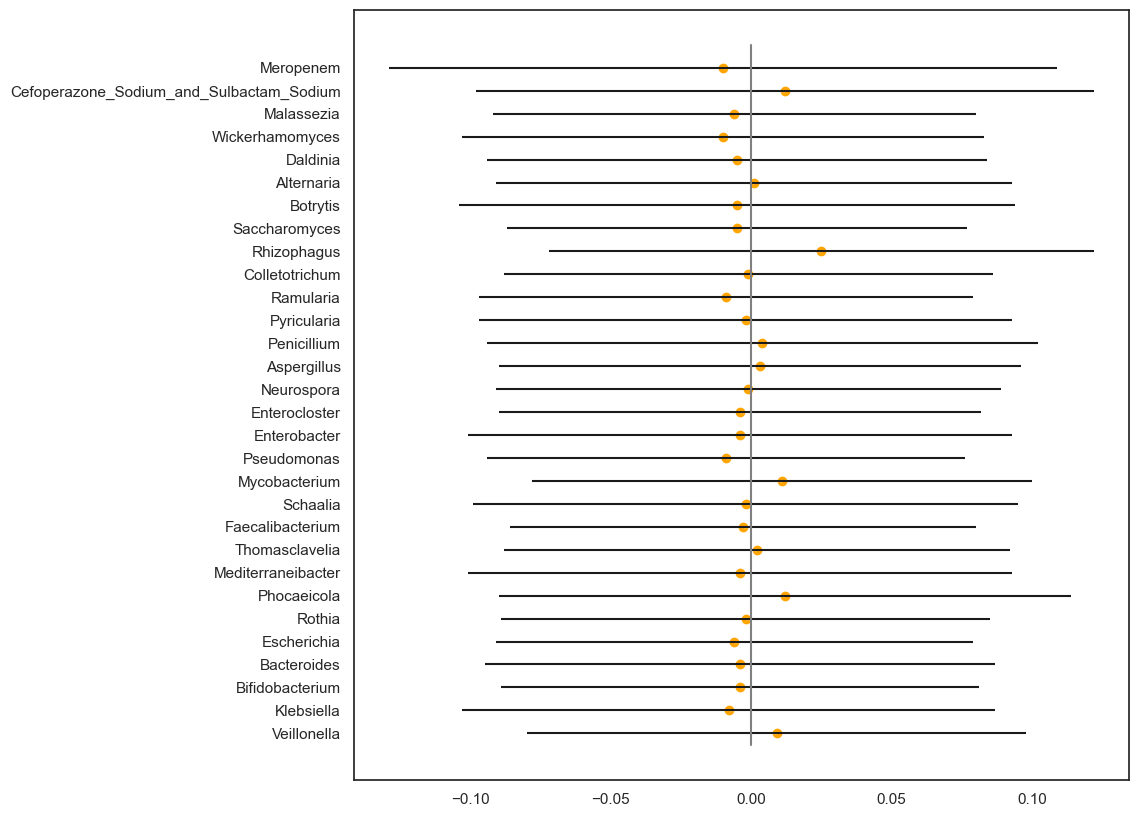

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 931 seconds.
There were 314 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.528215319047035, but should be close to 0.8. Try to increase the number of tuning steps.
There were 542 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5282869242977201, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use

Veillonella


<Figure size 640x480 with 0 Axes>

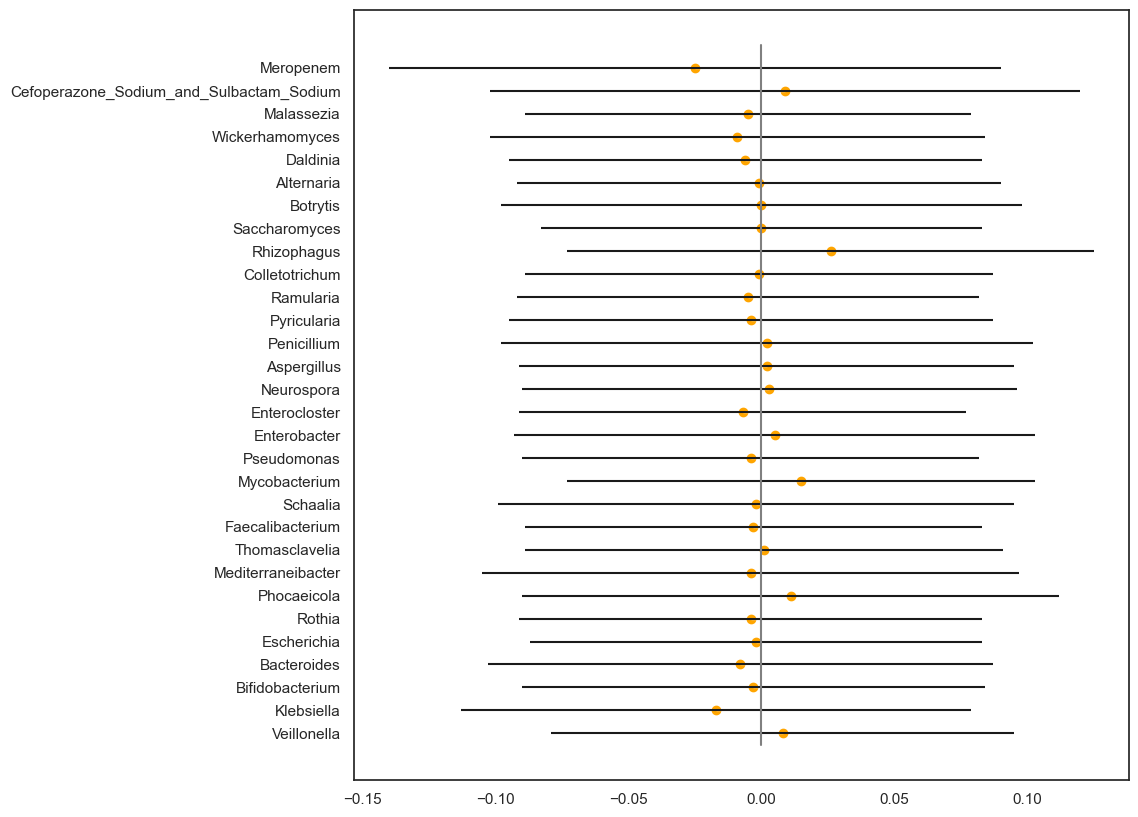

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 998 seconds.
There were 108 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7058462513232409, but should be close to 0.8. Try to increase the number of tuning steps.
There were 278 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5381264694704327, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the mode

Klebsiella


<Figure size 640x480 with 0 Axes>

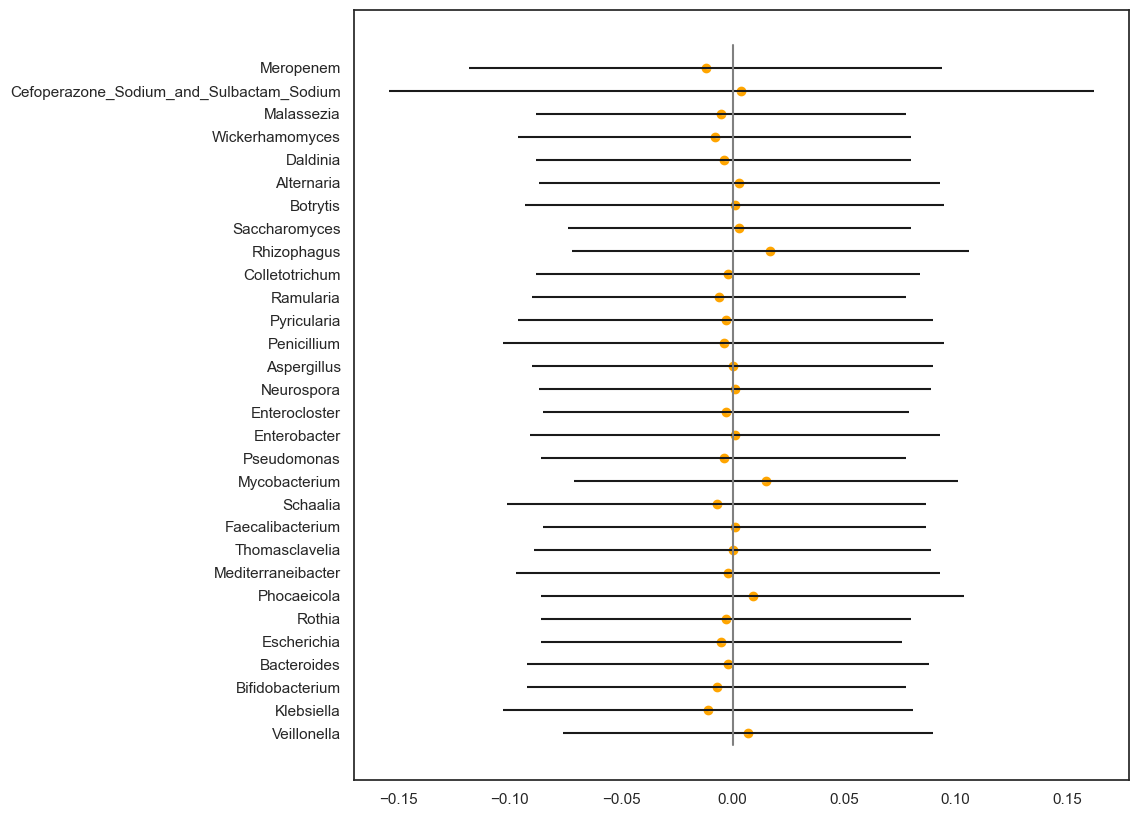

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1064 seconds.
There were 227 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6562610846676773, but should be close to 0.8. Try to increase the number of tuning steps.
There were 303 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Bifidobacterium


<Figure size 640x480 with 0 Axes>

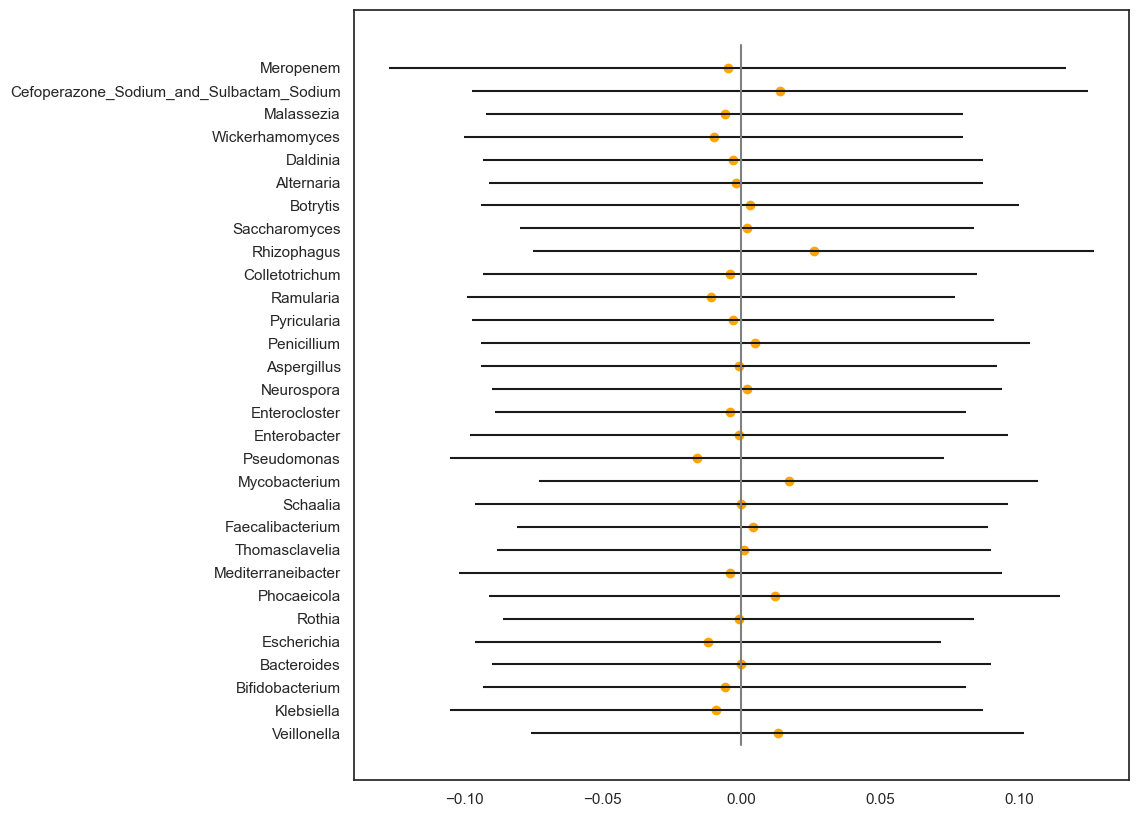

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 2547 seconds.
There were 108 divergences after tuning. Increase `target_accept` or reparameterize.
There were 1837 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.39661642273978903, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Enterococcus


<Figure size 640x480 with 0 Axes>

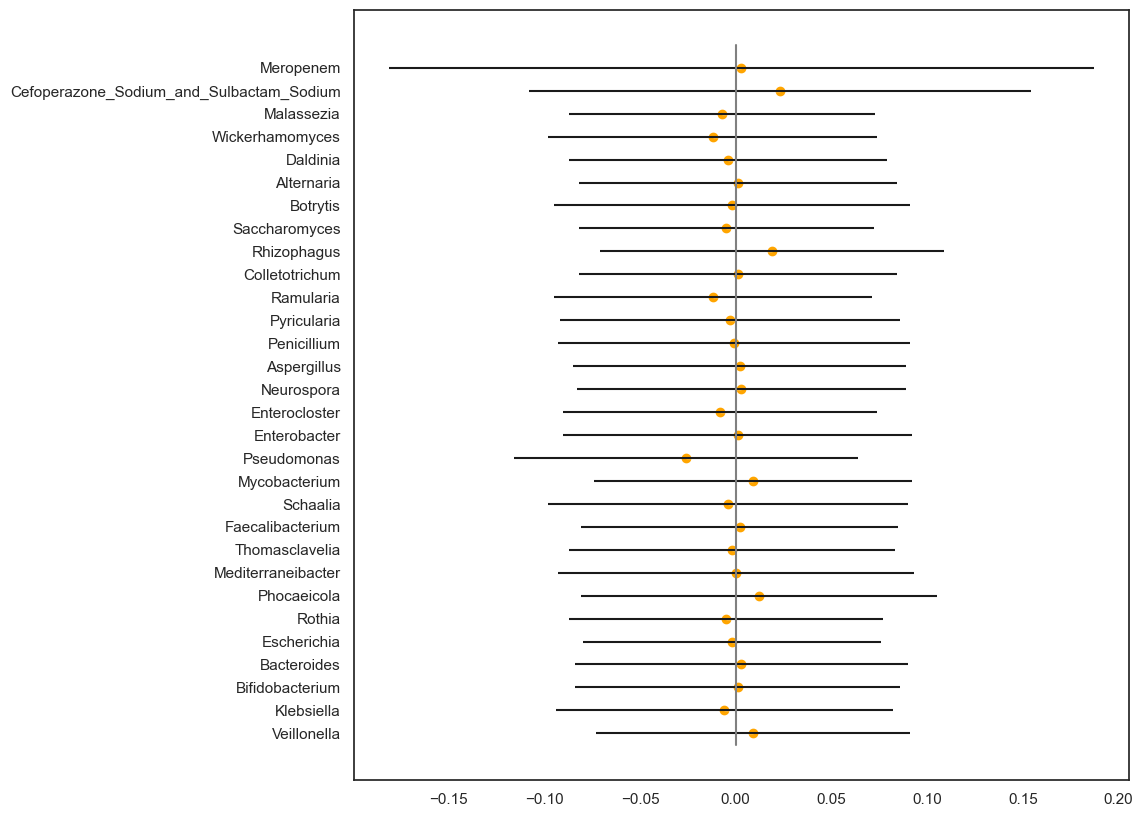

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1066 seconds.
D:\environment\envs\pymc3\lib\site-packages\arviz\stats\diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 126 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6400383802264573, but should be close to 0.8. Try to increase the number of tuning steps.
There were 219 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will re

Bacteroides


<Figure size 640x480 with 0 Axes>

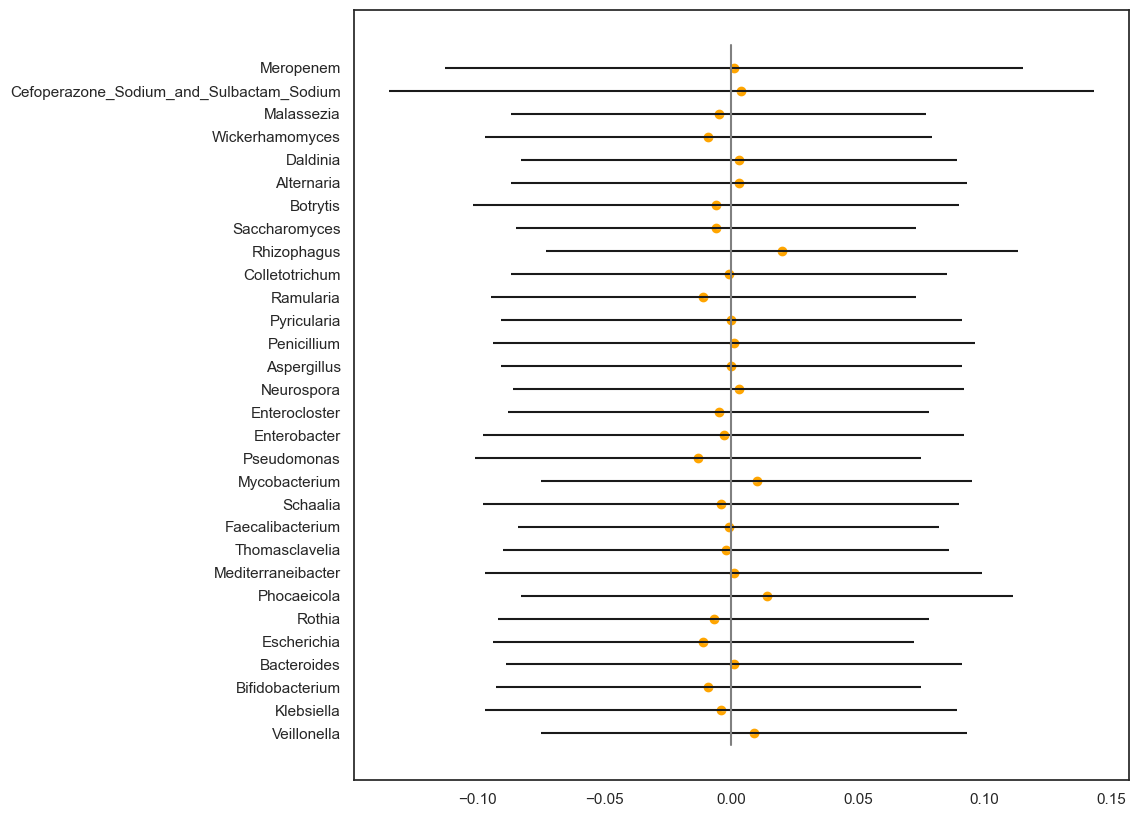

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1122 seconds.
There were 201 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7163648221371154, but should be close to 0.8. Try to increase the number of tuning steps.
There were 258 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7131203918481579, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the mod

Escherichia


<Figure size 640x480 with 0 Axes>

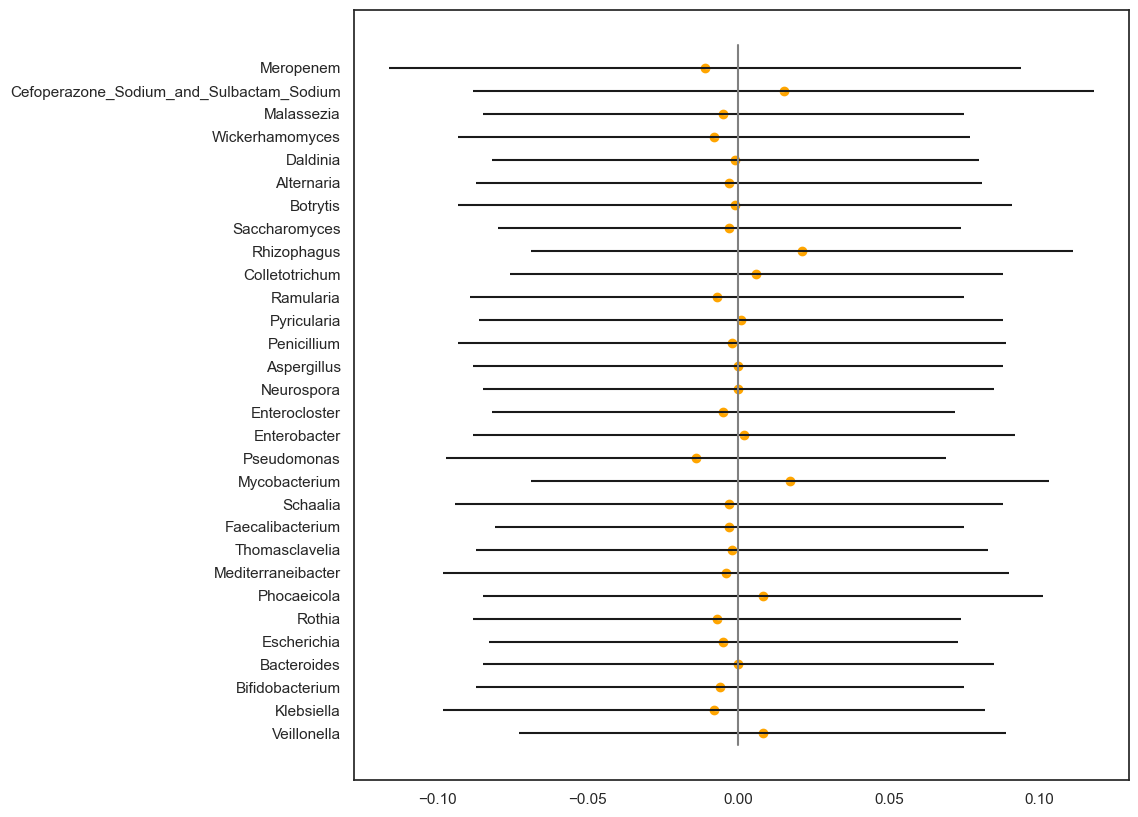

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1234 seconds.
There were 82 divergences after tuning. Increase `target_accept` or reparameterize.
There were 160 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Rothia


<Figure size 640x480 with 0 Axes>

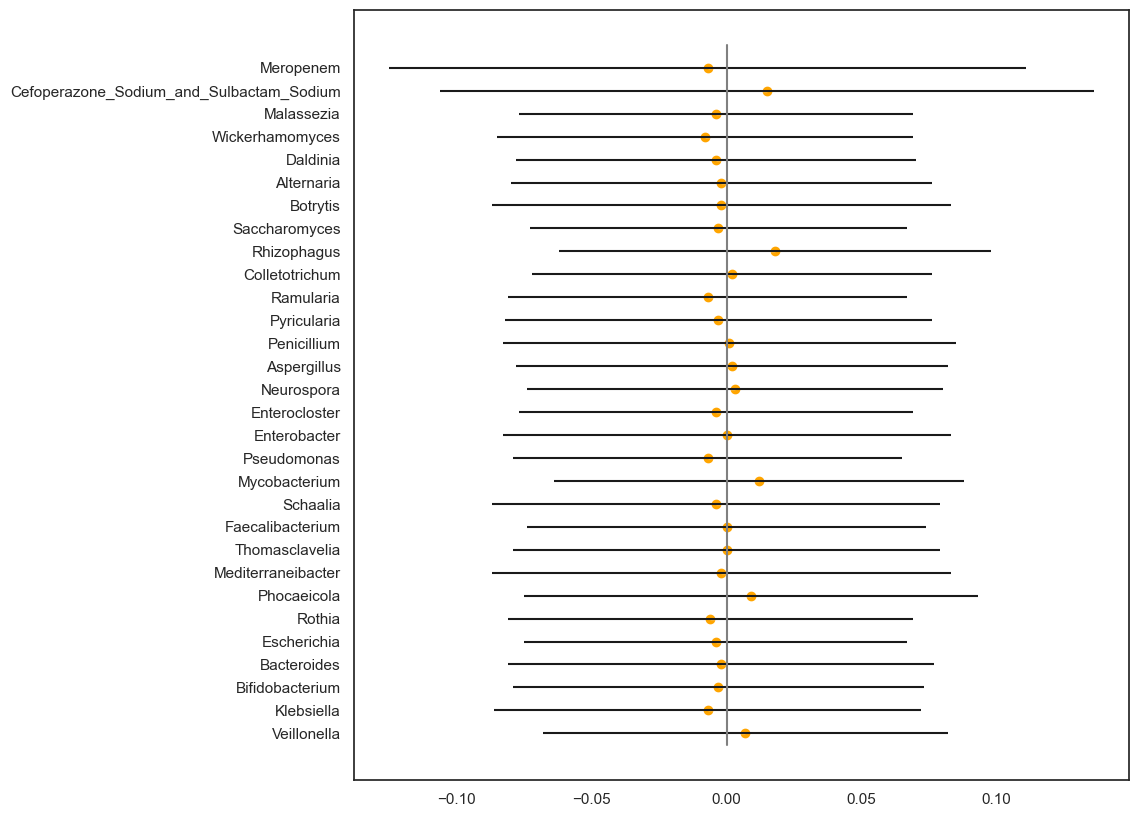

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1250 seconds.
There were 115 divergences after tuning. Increase `target_accept` or reparameterize.
There were 256 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Phocaeicola


<Figure size 640x480 with 0 Axes>

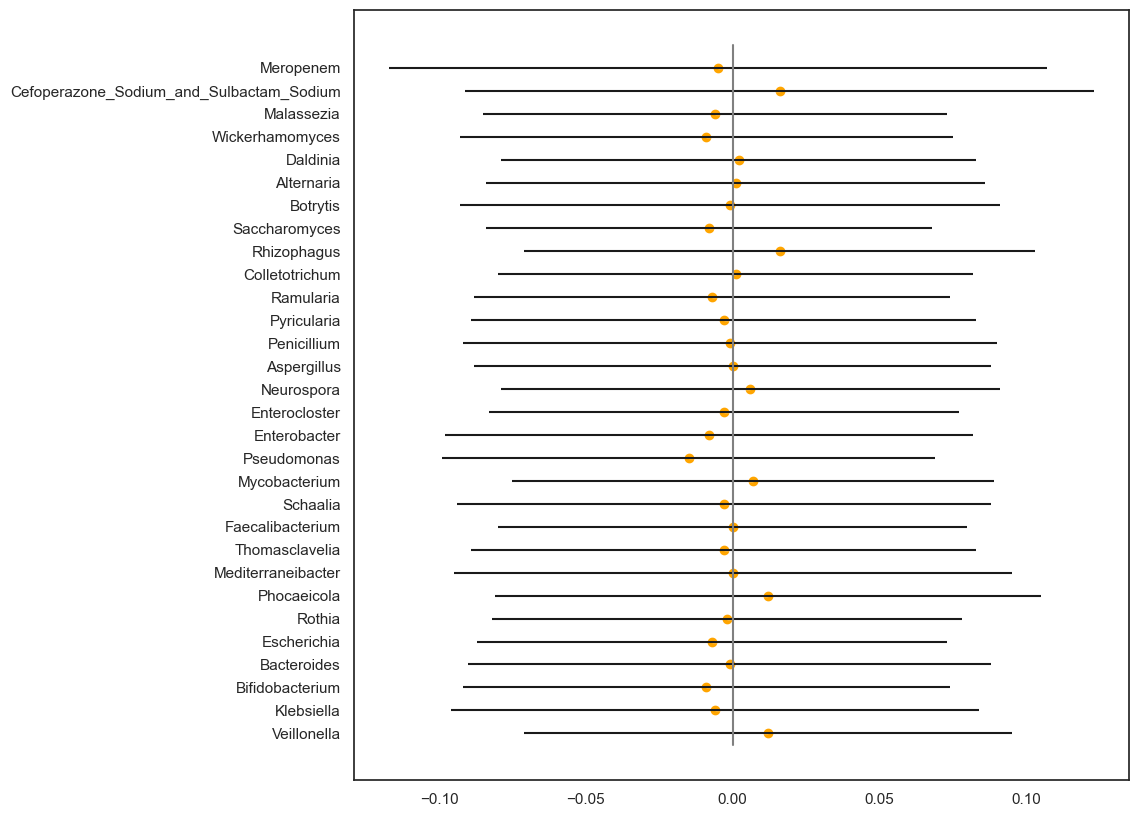

(211, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1157 seconds.
There were 76 divergences after tuning. Increase `target_accept` or reparameterize.
There were 336 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6122385937341871, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Mediterraneibacter


<Figure size 640x480 with 0 Axes>

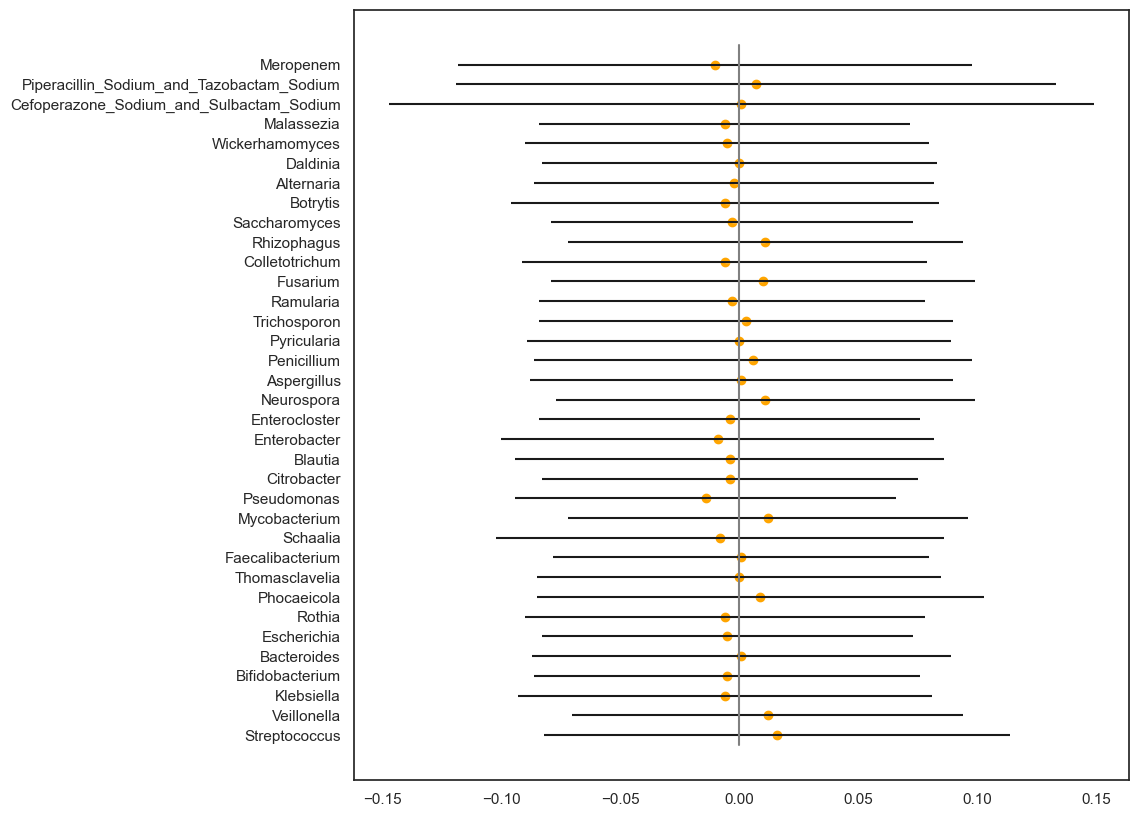

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1091 seconds.
There were 161 divergences after tuning. Increase `target_accept` or reparameterize.
There were 441 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6871442724690616, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Thomasclavelia


<Figure size 640x480 with 0 Axes>

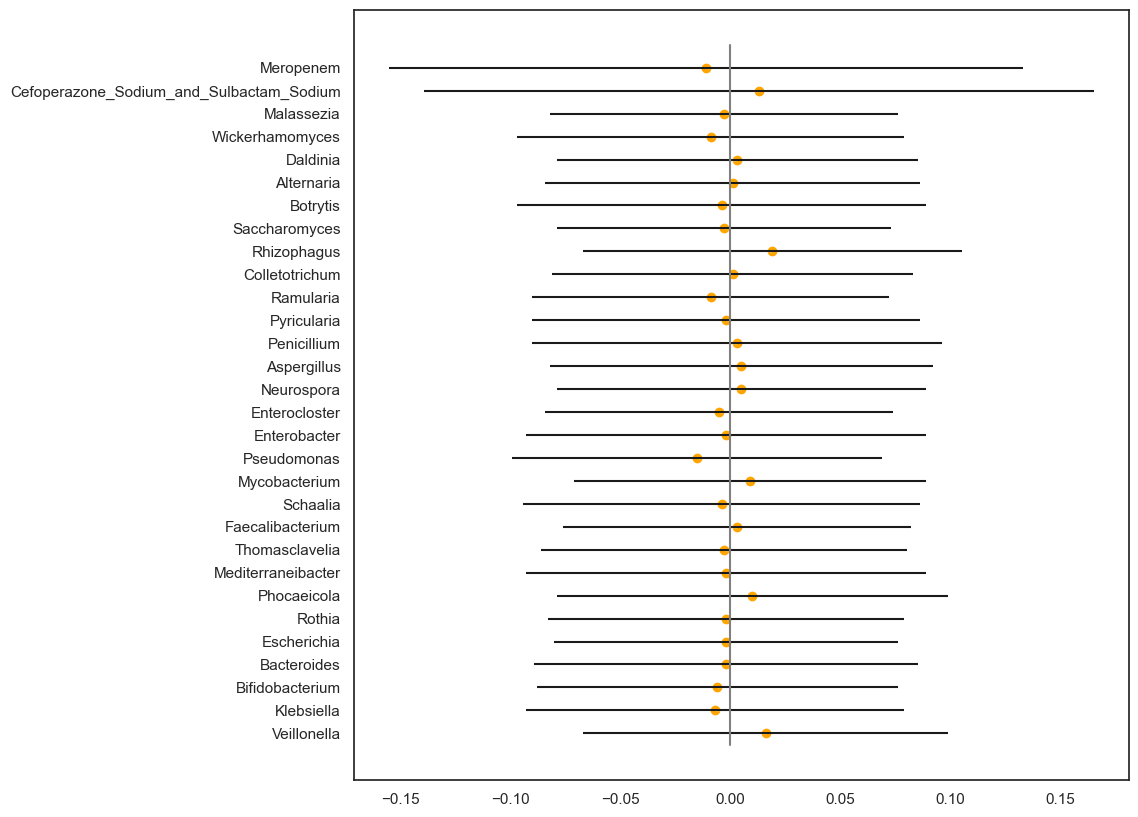

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1175 seconds.
There were 152 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6482418222887518, but should be close to 0.8. Try to increase the number of tuning steps.
There were 231 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Faecalibacterium


<Figure size 640x480 with 0 Axes>

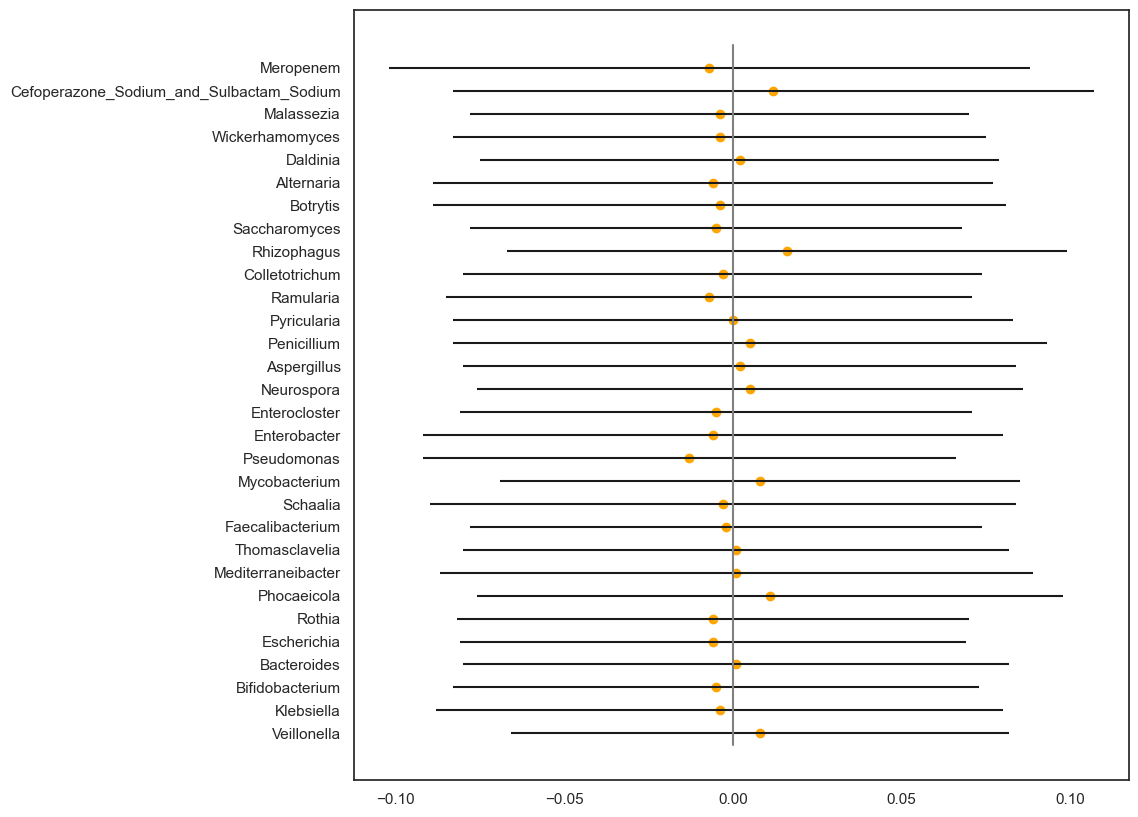

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1140 seconds.
There were 325 divergences after tuning. Increase `target_accept` or reparameterize.
There were 384 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Schaalia


<Figure size 640x480 with 0 Axes>

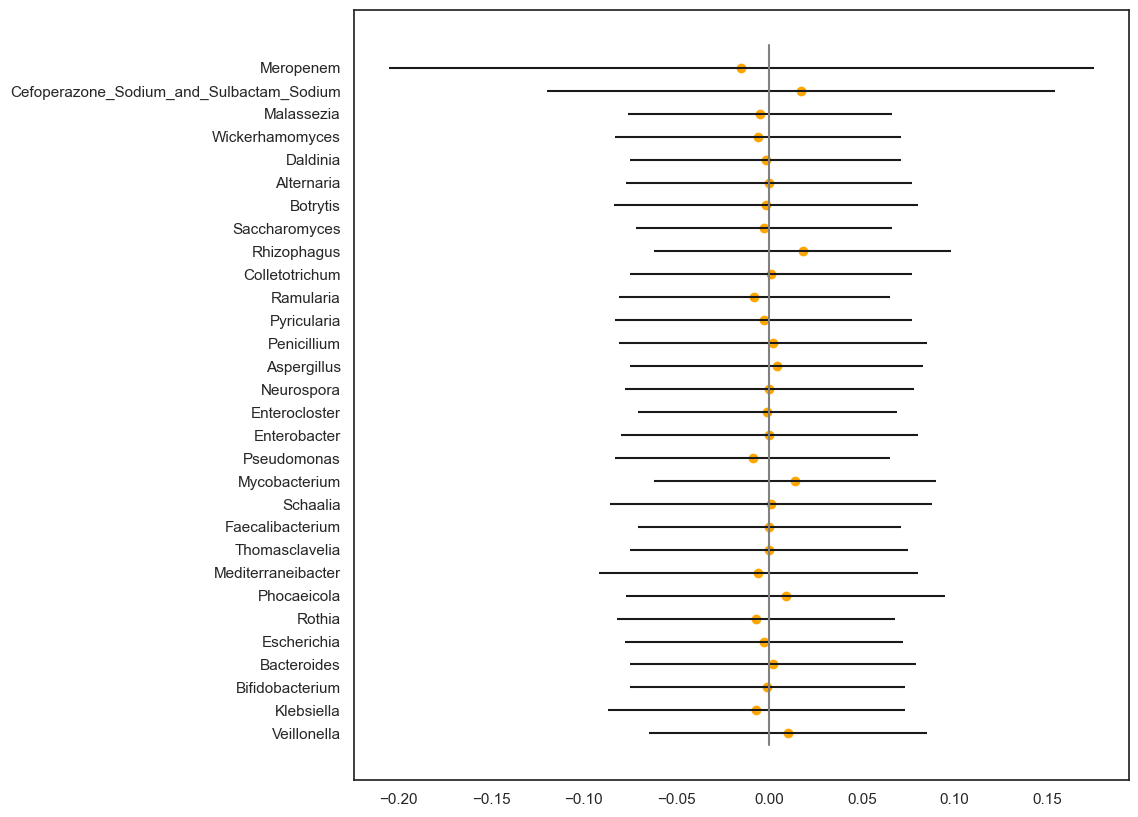

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1085 seconds.
There were 159 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7121766688590268, but should be close to 0.8. Try to increase the number of tuning steps.
There were 453 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6648603580698025, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you u

Mycobacterium


<Figure size 640x480 with 0 Axes>

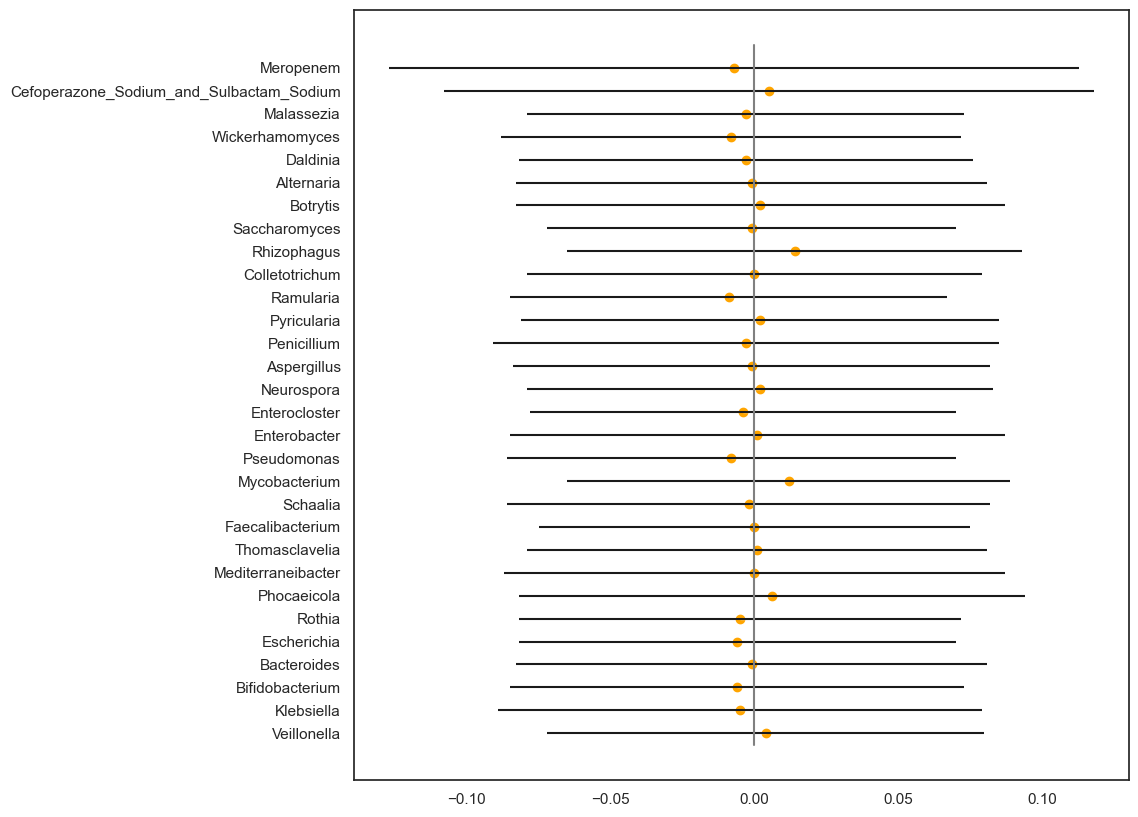

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1095 seconds.
There were 38 divergences after tuning. Increase `target_accept` or reparameterize.
There were 169 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6314313899468181, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Pseudomonas


<Figure size 640x480 with 0 Axes>

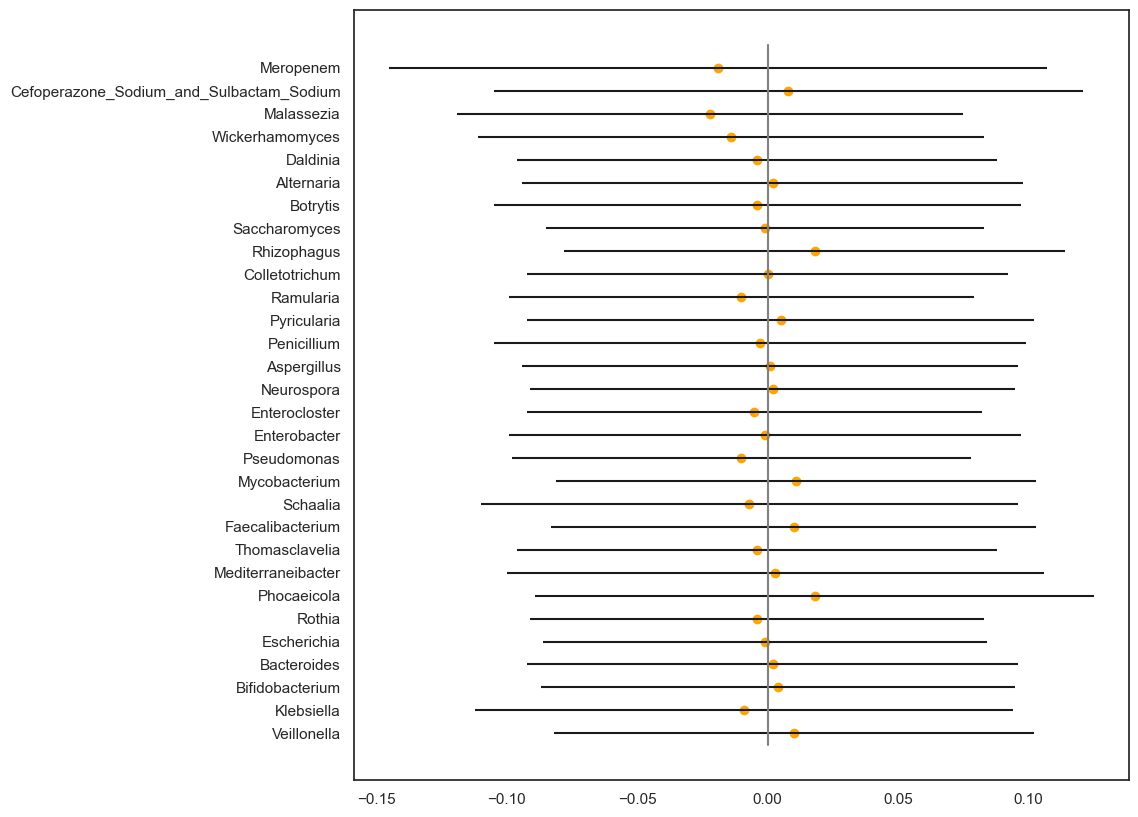

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1401 seconds.
There were 128 divergences after tuning. Increase `target_accept` or reparameterize.
There were 963 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Citrobacter


<Figure size 640x480 with 0 Axes>

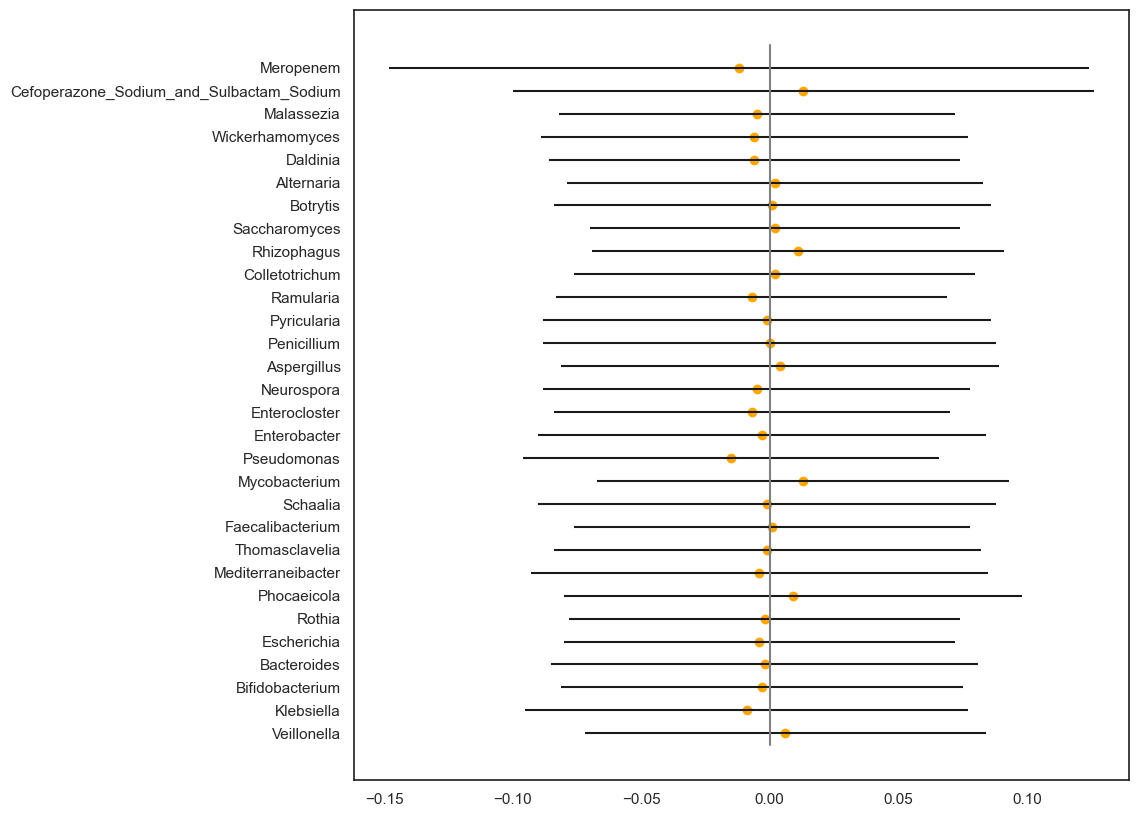

(209, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1180 seconds.
There were 68 divergences after tuning. Increase `target_accept` or reparameterize.
There were 128 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Blautia


<Figure size 640x480 with 0 Axes>

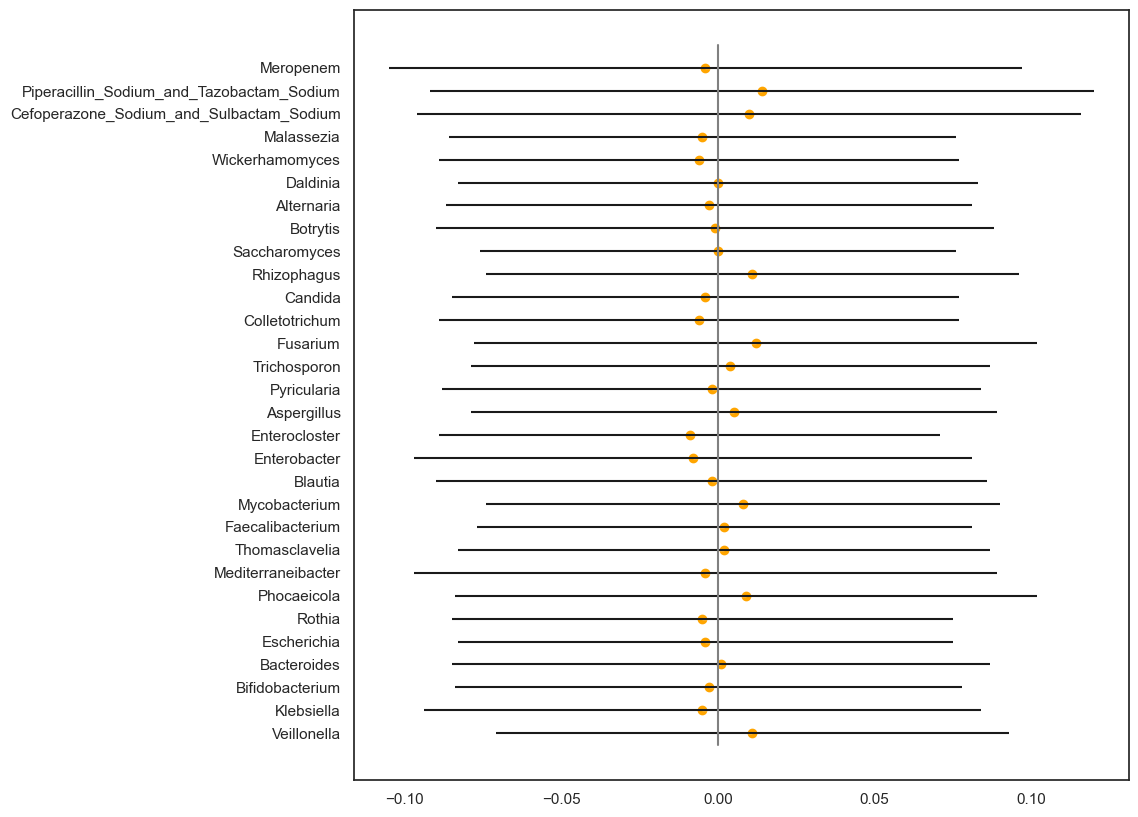

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1217 seconds.
There were 171 divergences after tuning. Increase `target_accept` or reparameterize.
There were 566 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Enterobacter


<Figure size 640x480 with 0 Axes>

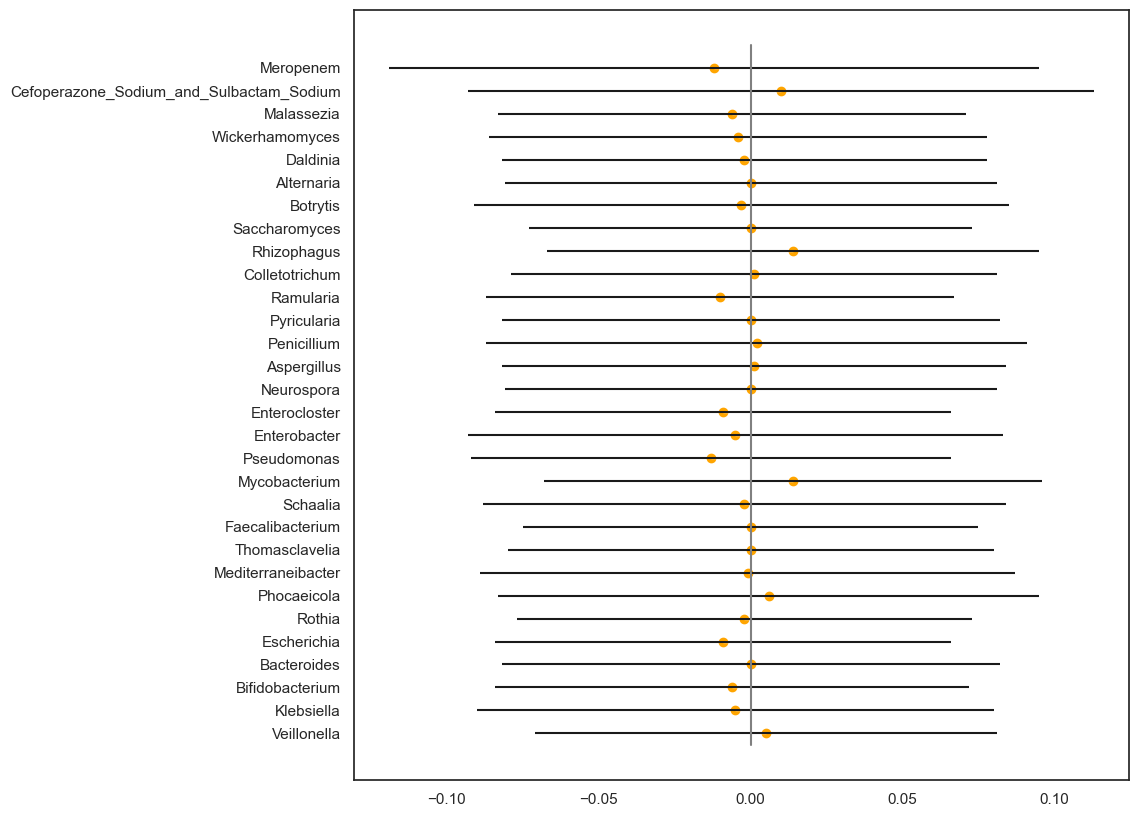

(202, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1238 seconds.
There were 1495 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.39083643944780877, but should be close to 0.8. Try to increase the number of tuning steps.
There were 1729 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.05 for some parameters. This indicates slight problems during sampling.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 

Enterocloster


<Figure size 640x480 with 0 Axes>

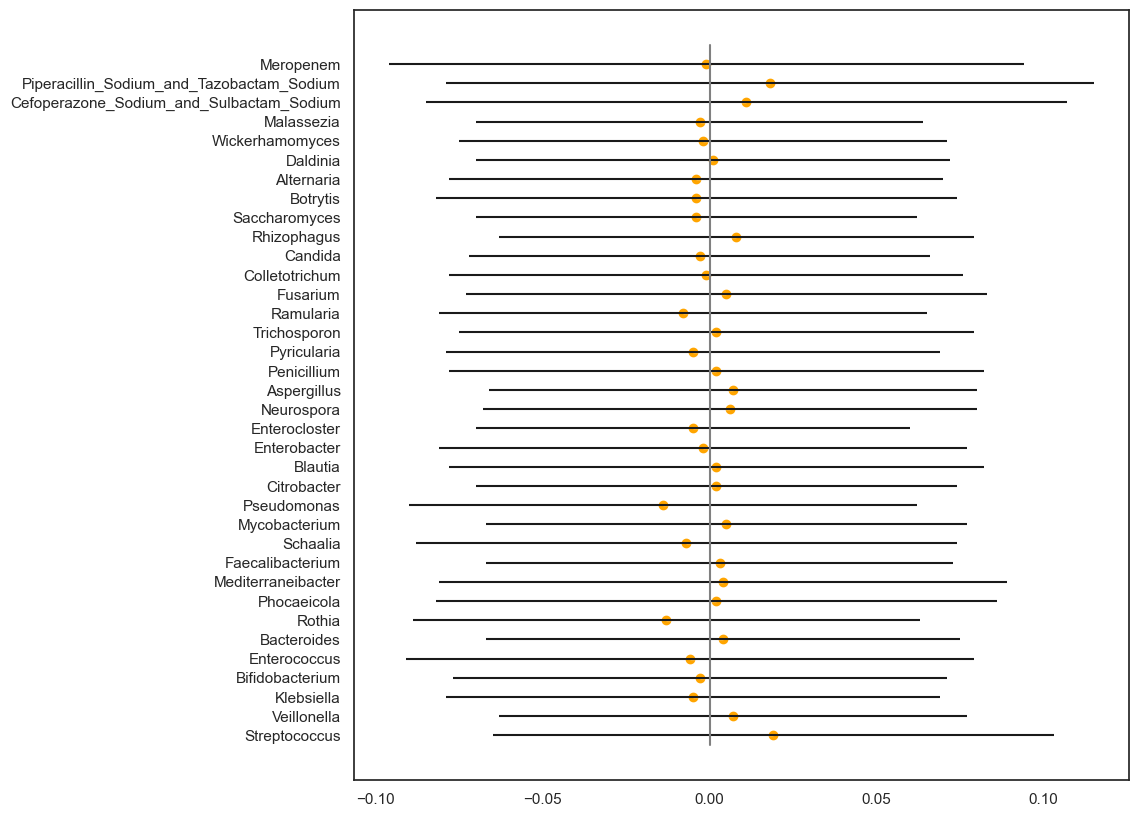

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1371 seconds.
There were 273 divergences after tuning. Increase `target_accept` or reparameterize.
There were 750 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Neurospora


<Figure size 640x480 with 0 Axes>

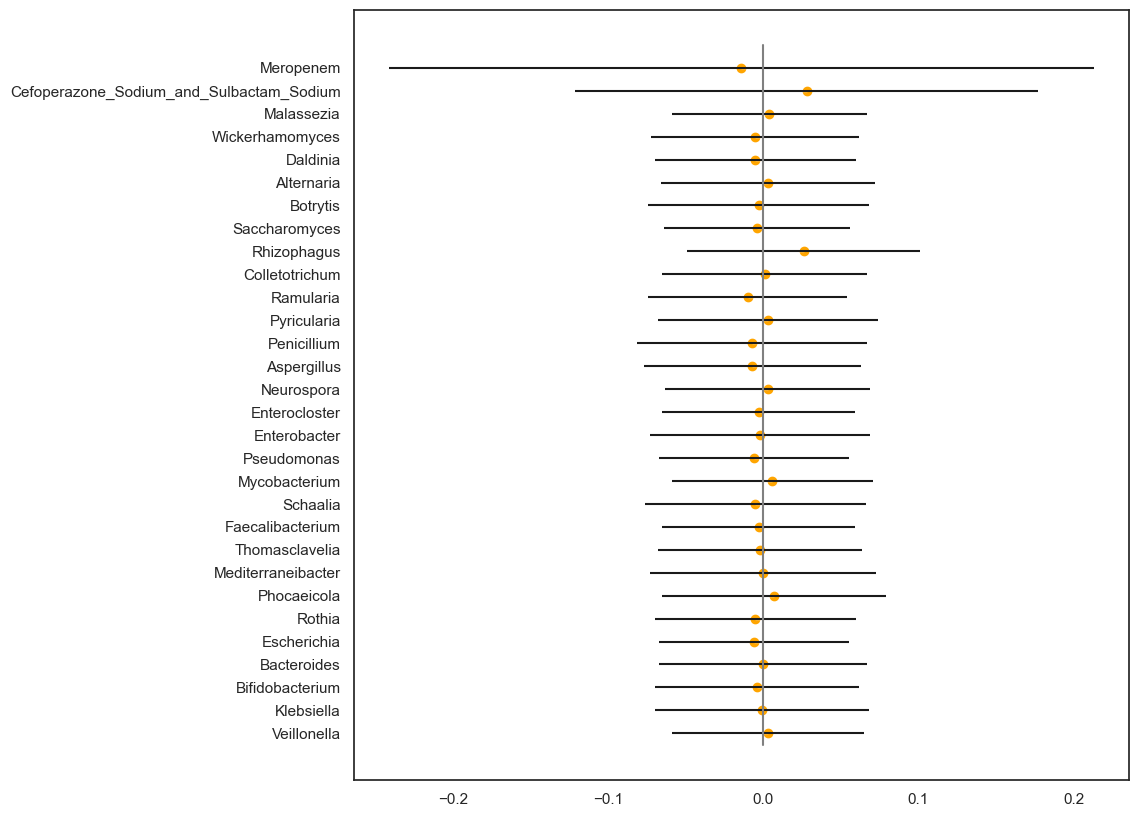

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1138 seconds.
There were 192 divergences after tuning. Increase `target_accept` or reparameterize.
There were 289 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Aspergillus


<Figure size 640x480 with 0 Axes>

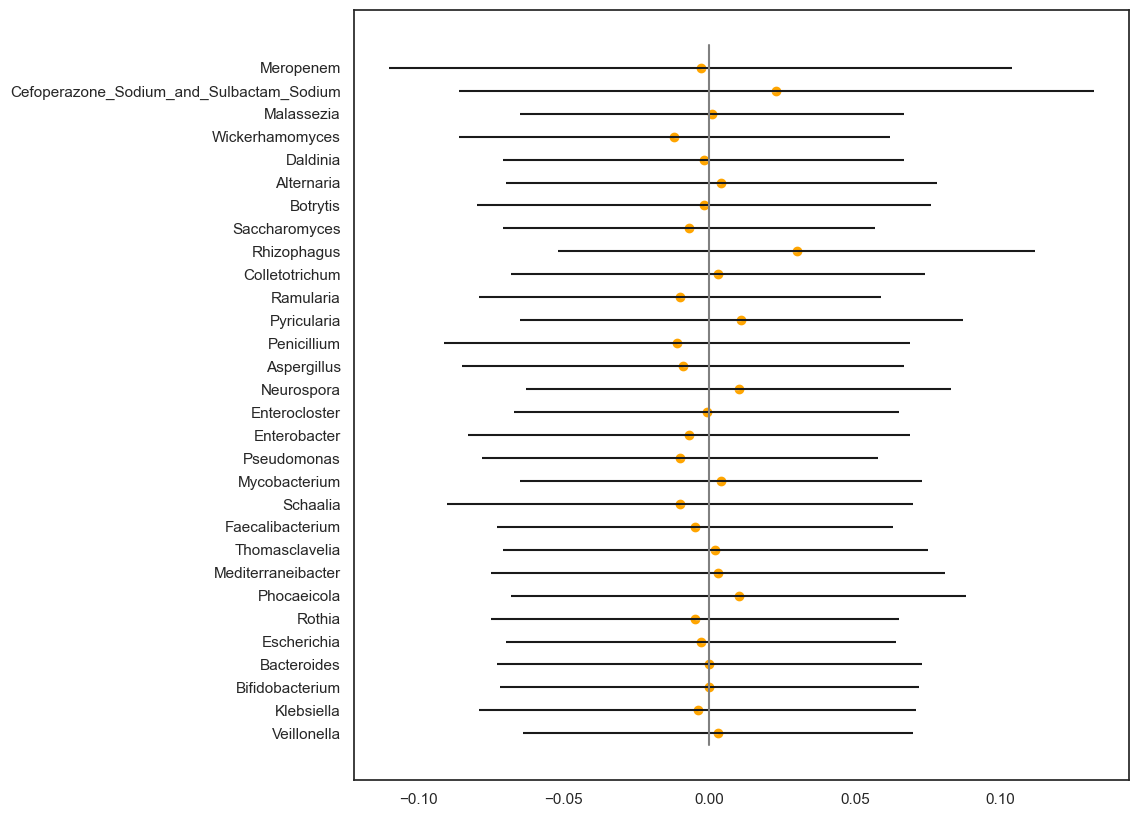

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1045 seconds.
There were 127 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.638512287719552, but should be close to 0.8. Try to increase the number of tuning steps.
There were 204 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Penicillium


<Figure size 640x480 with 0 Axes>

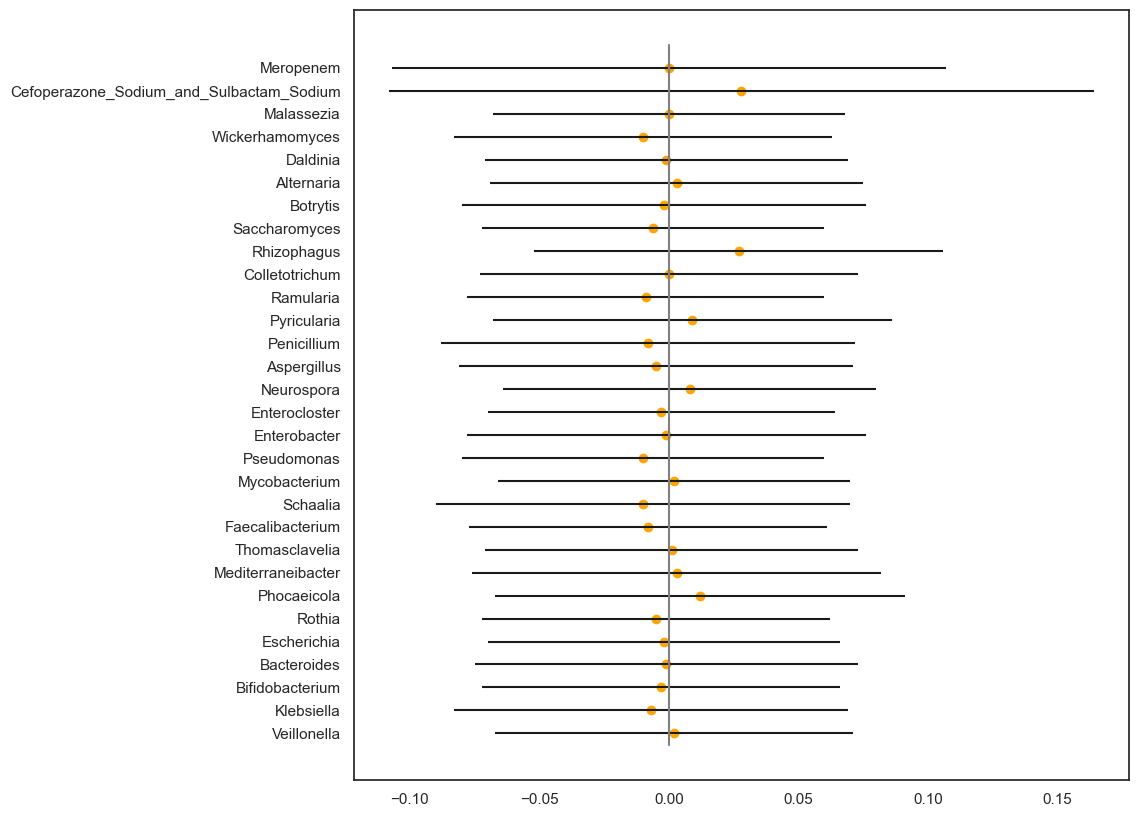

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1241 seconds.
There were 193 divergences after tuning. Increase `target_accept` or reparameterize.
There were 504 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Pyricularia


<Figure size 640x480 with 0 Axes>

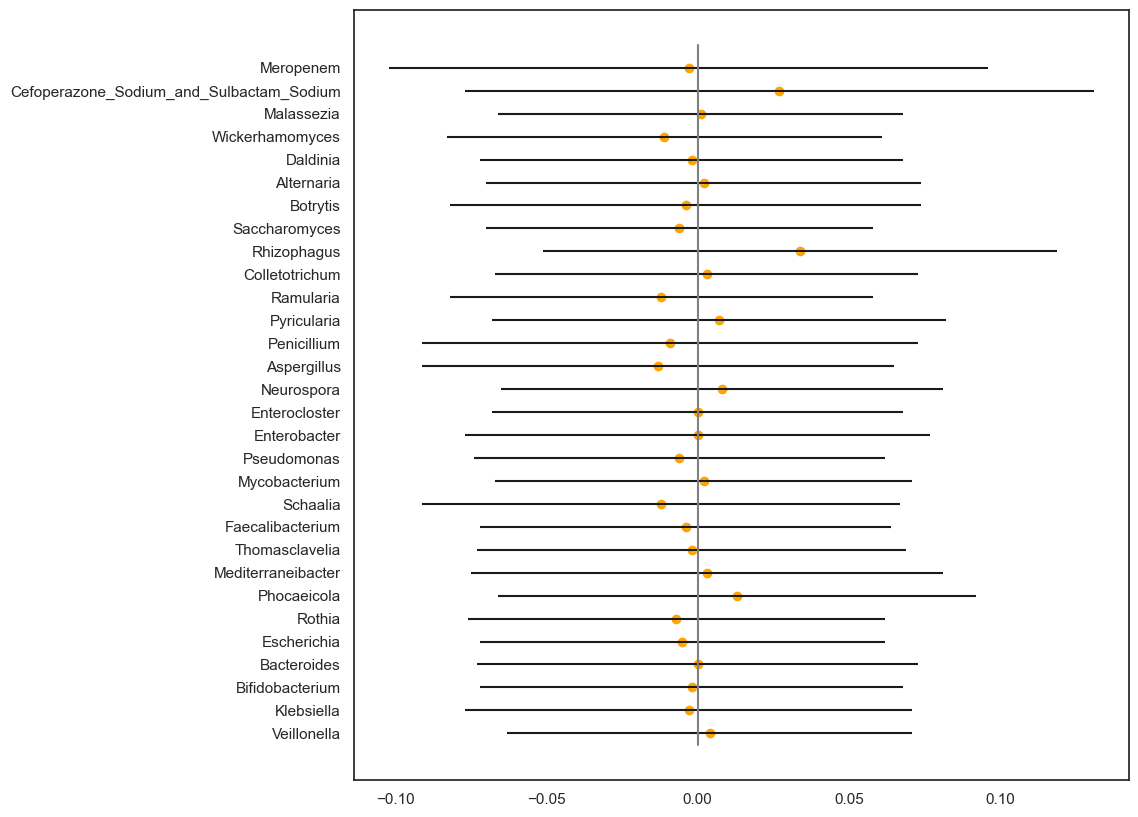

(211, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1376 seconds.
There were 228 divergences after tuning. Increase `target_accept` or reparameterize.
There were 570 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6820790674803127, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Trichosporon


<Figure size 640x480 with 0 Axes>

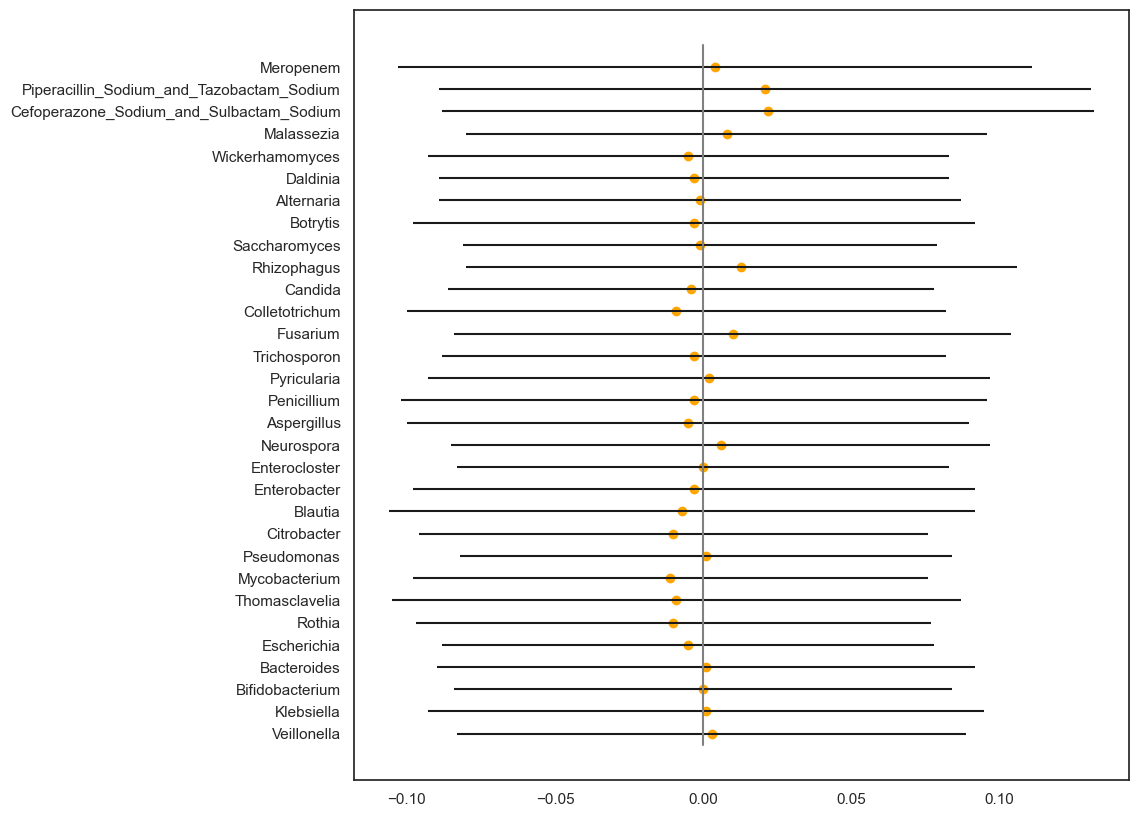

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1176 seconds.
There were 286 divergences after tuning. Increase `target_accept` or reparameterize.
There were 1170 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.713210289059168, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Ramularia


<Figure size 640x480 with 0 Axes>

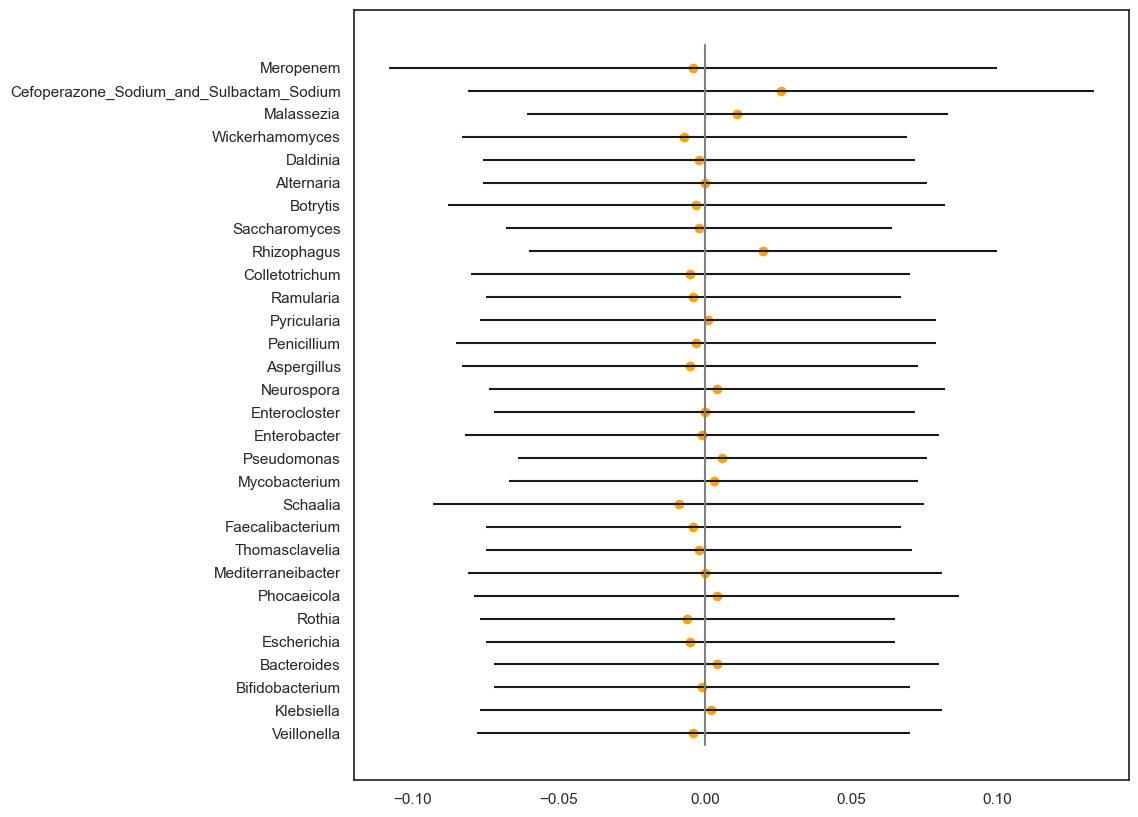

(213, 2)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1130 seconds.
There were 84 divergences after tuning. Increase `target_accept` or reparameterize.
There were 217 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6363625694782676, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Fusarium


<Figure size 640x480 with 0 Axes>

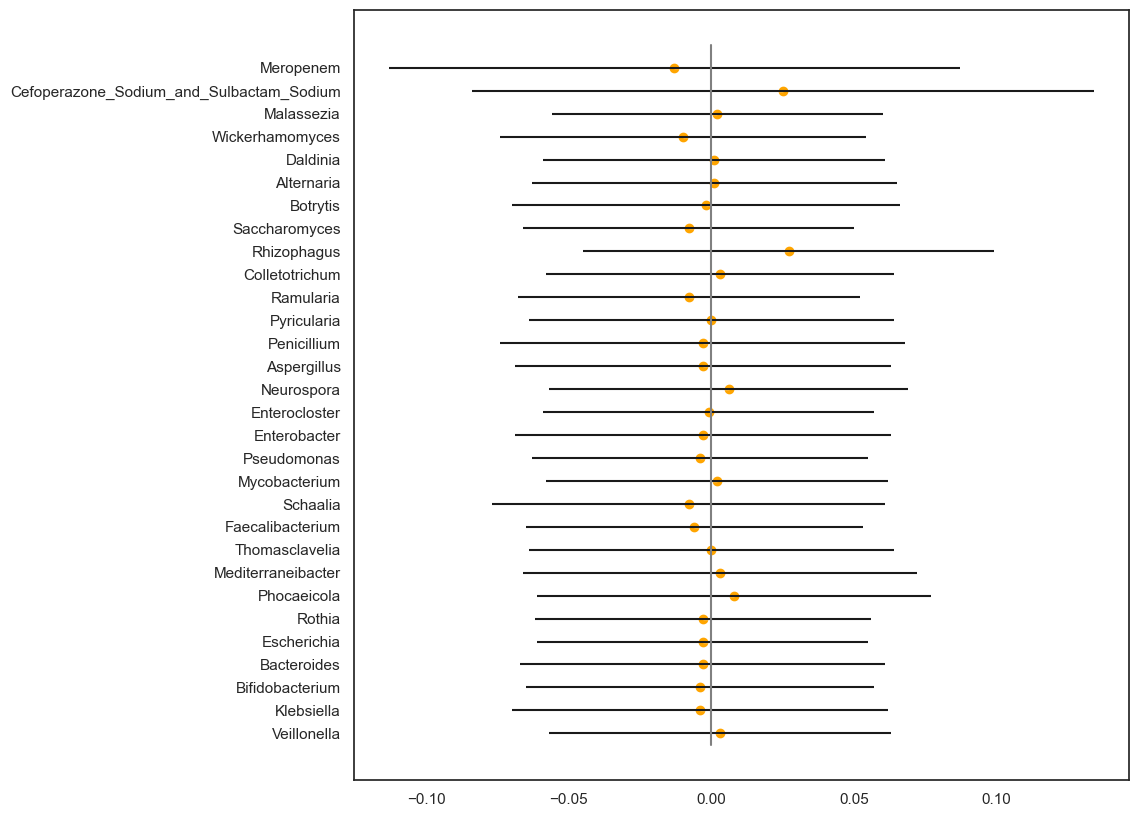

(209, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1143 seconds.
There were 86 divergences after tuning. Increase `target_accept` or reparameterize.
There were 255 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7024261973788724, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Colletotrichum


<Figure size 640x480 with 0 Axes>

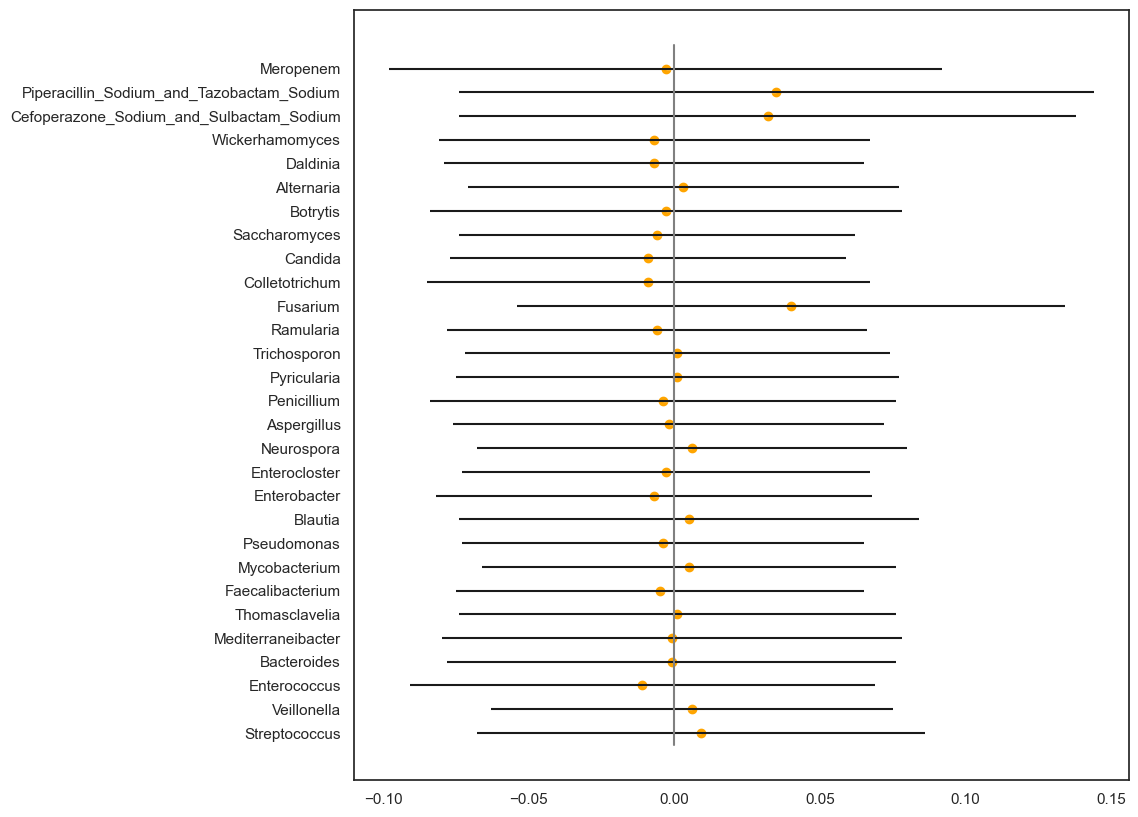

(206, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1255 seconds.
There were 202 divergences after tuning. Increase `target_accept` or reparameterize.
There were 275 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Candida


<Figure size 640x480 with 0 Axes>

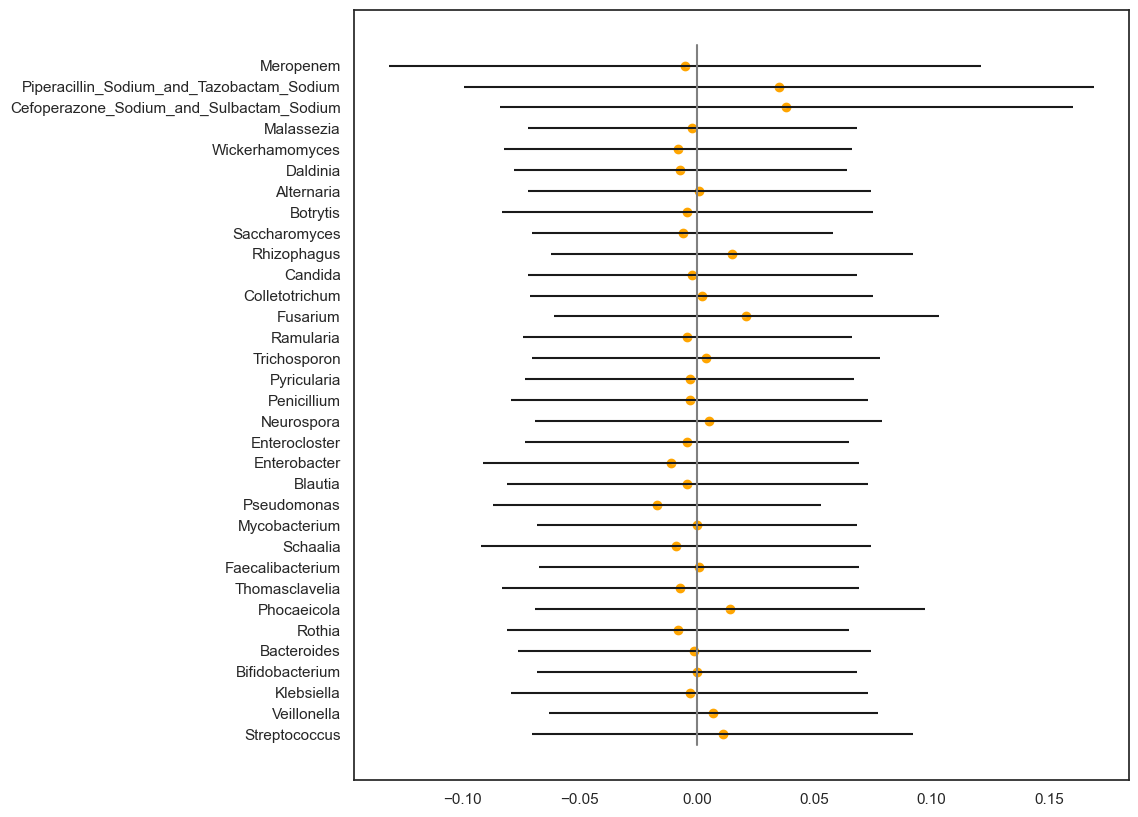

(209, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1219 seconds.
D:\environment\envs\pymc3\lib\site-packages\arviz\stats\diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 510 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6448810585259952, but should be close to 0.8. Try to increase the number of tuning steps.
There were 677 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7005138030330134, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\s

Rhizophagus


<Figure size 640x480 with 0 Axes>

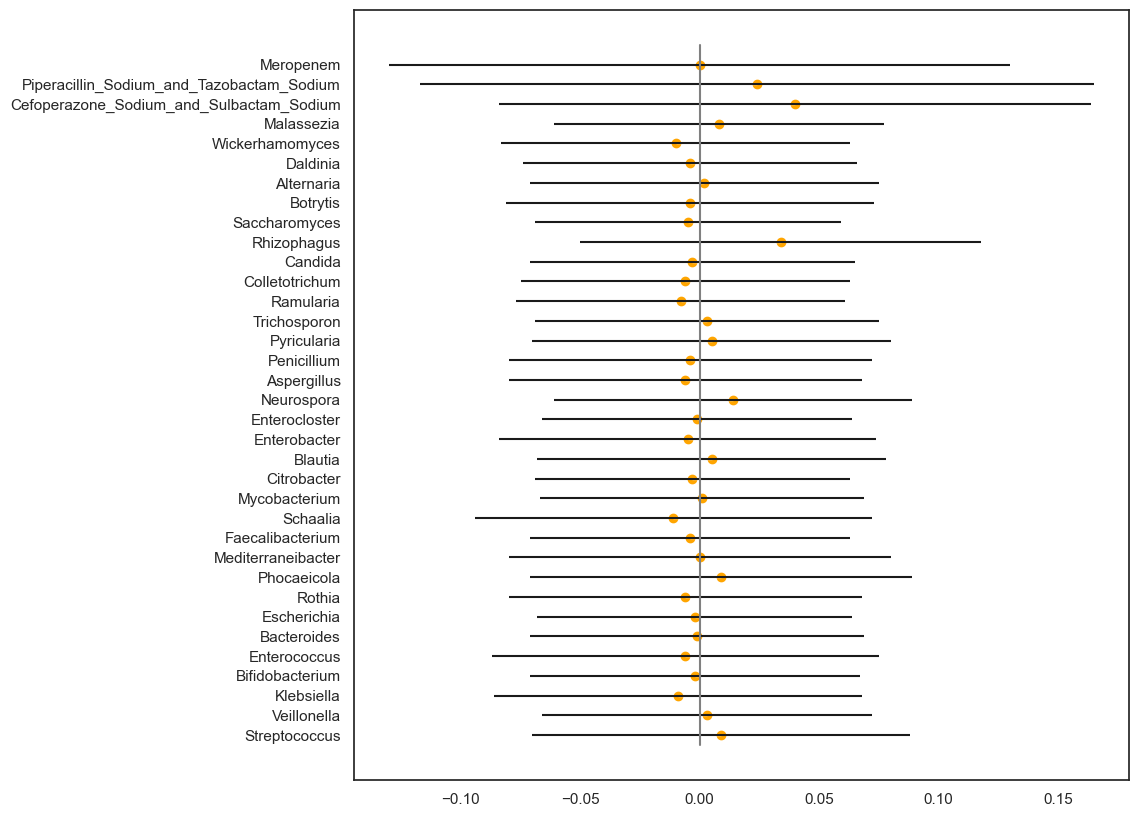

(192, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1319 seconds.
There were 118 divergences after tuning. Increase `target_accept` or reparameterize.
There were 255 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7024395225003699, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Saccharomyces


<Figure size 640x480 with 0 Axes>

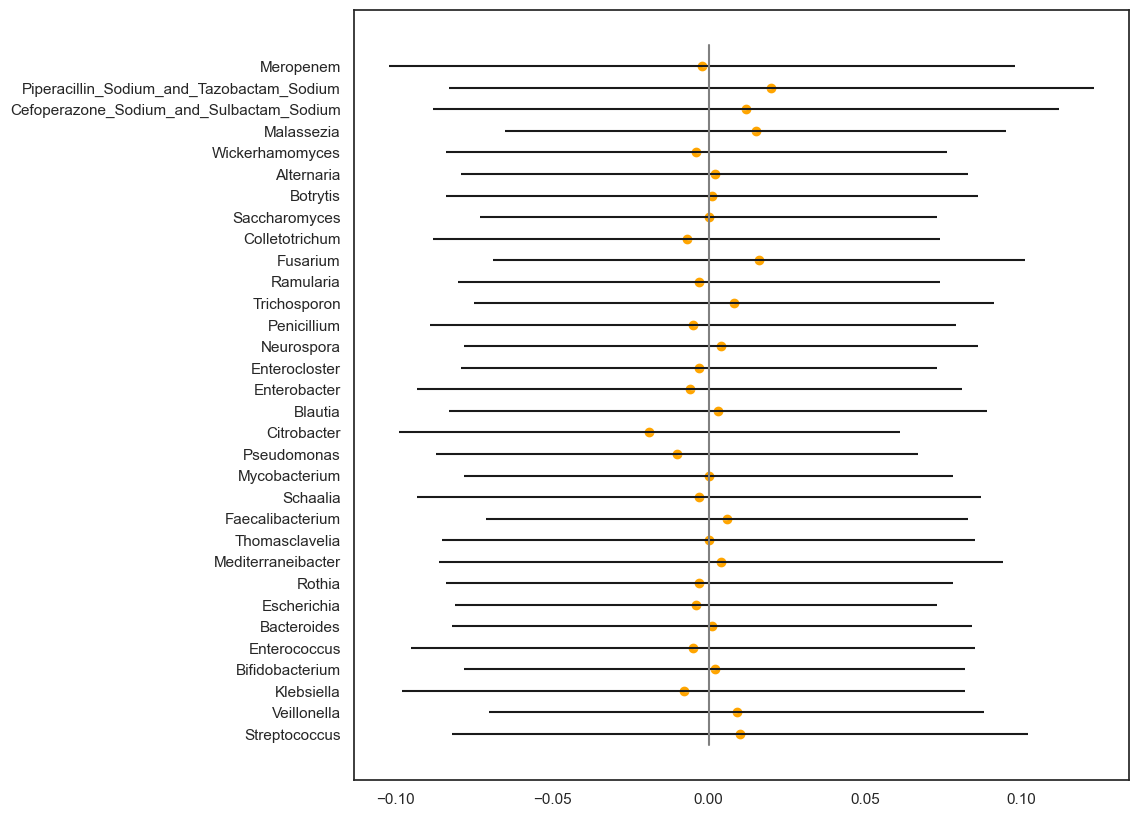

(202, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1135 seconds.
There were 186 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6744194734975004, but should be close to 0.8. Try to increase the number of tuning steps.
There were 280 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.5943600545830875, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the mod

Botrytis


<Figure size 640x480 with 0 Axes>

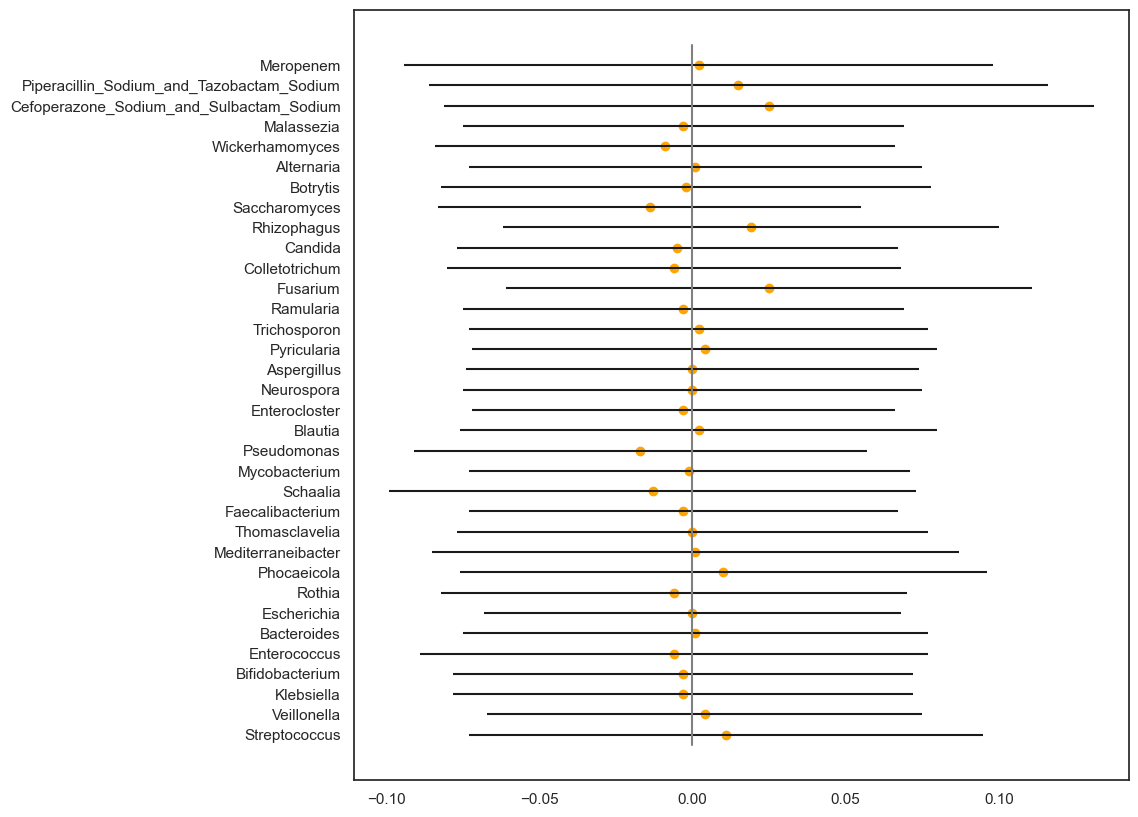

(181, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1211 seconds.
There were 298 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6605981818545004, but should be close to 0.8. Try to increase the number of tuning steps.
There were 421 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6959808495345791, but should be close to 0.8. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you u

Alternaria


<Figure size 640x480 with 0 Axes>

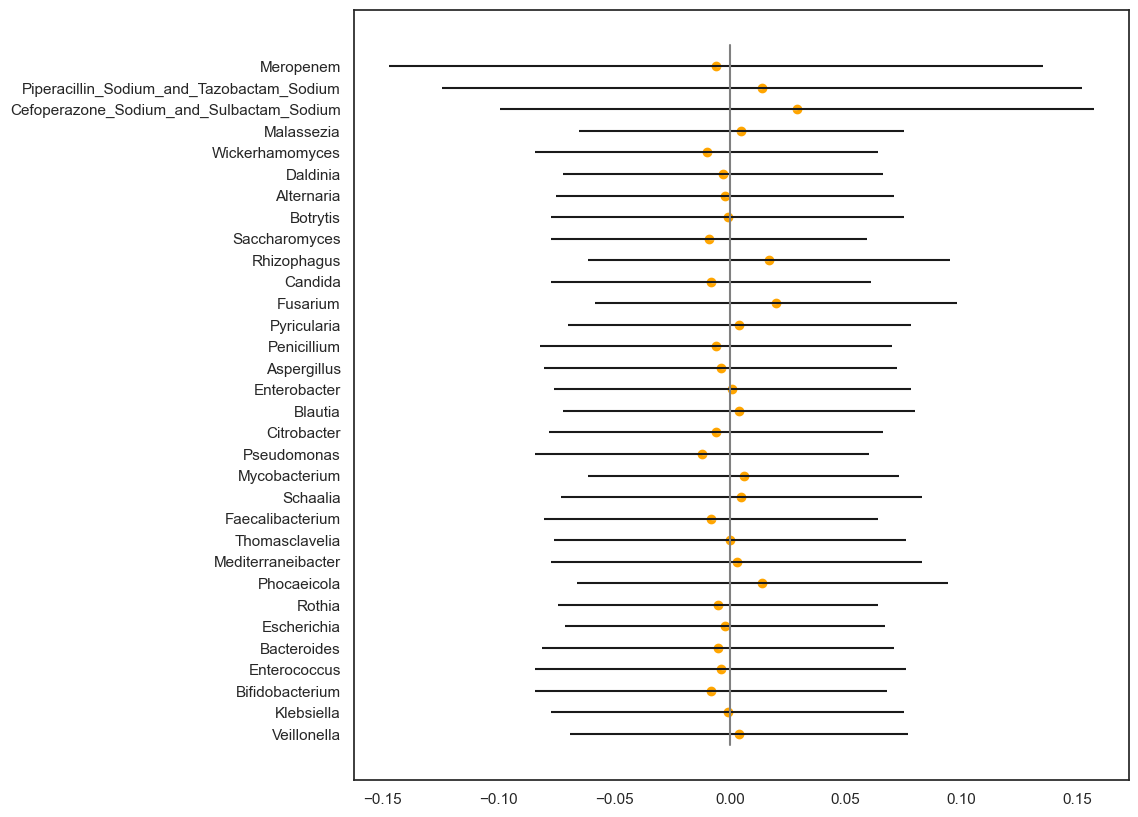

(169, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1164 seconds.
There were 242 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6223049228219886, but should be close to 0.8. Try to increase the number of tuning steps.
There were 511 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.6643612588075842, but should be close to 0.8. Try to increase the number of tuning steps.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the mod

Daldinia


<Figure size 640x480 with 0 Axes>

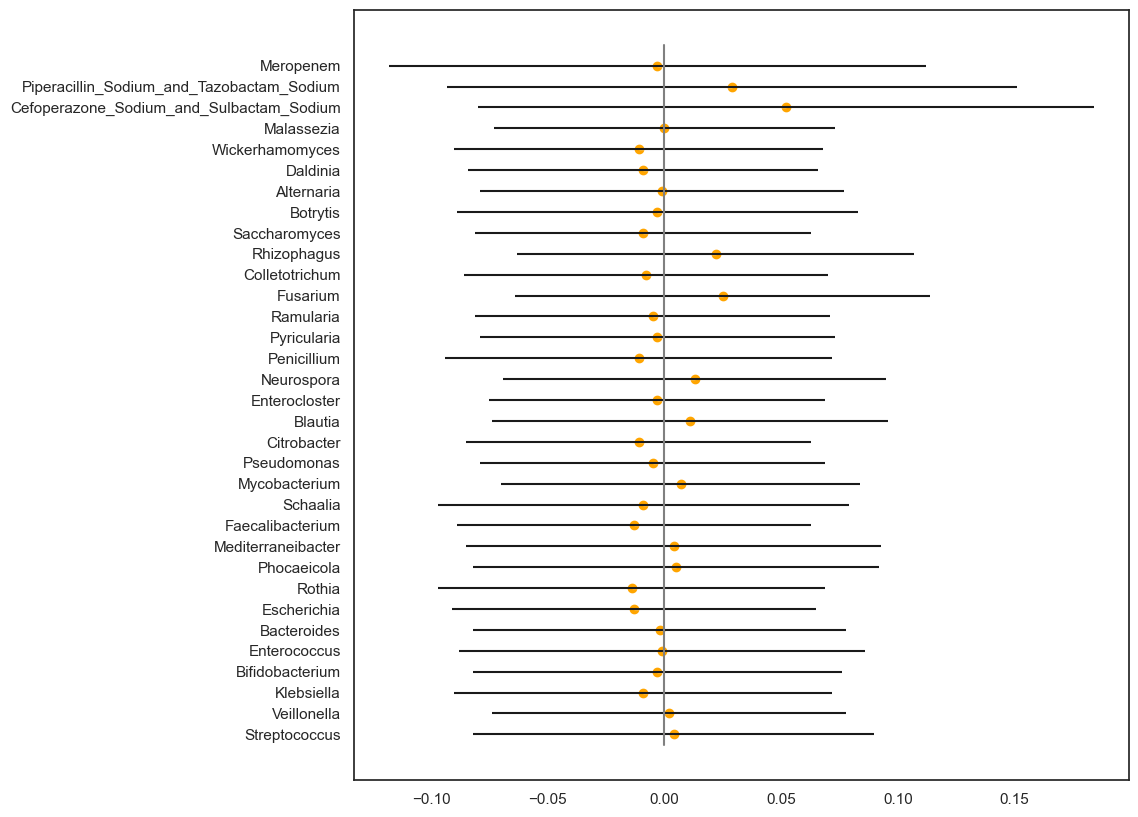

(160, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1271 seconds.
There were 197 divergences after tuning. Increase `target_accept` or reparameterize.
There were 501 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Wickerhamomyces


<Figure size 640x480 with 0 Axes>

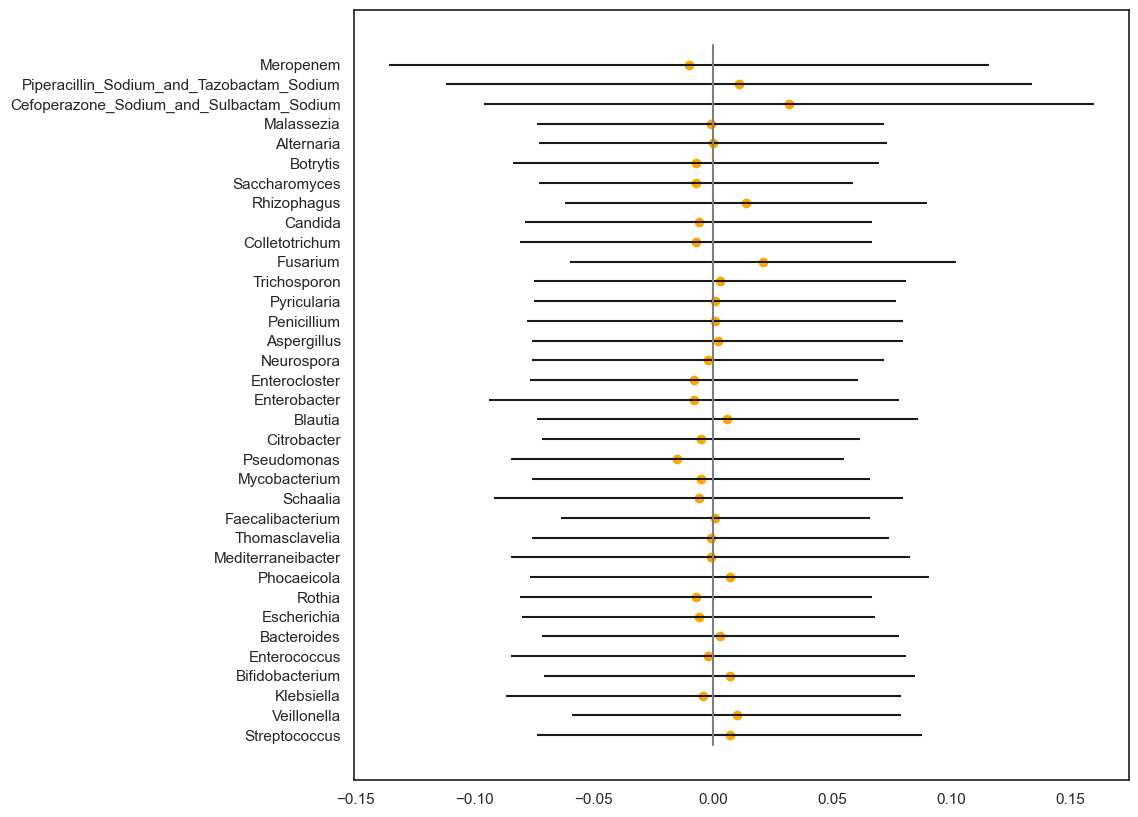

(193, 3)


The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
D:\environment\envs\pymc3\lib\site-packages\deprecat\classic.py:232: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Sequential sampling (2 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [xi_taxa, xi_drugs]
>NUTS: [intercp, my_sigma, beta_drugs, tau_drugs, beta_taxa, tau_taxa]


Sampling 2 chains for 2_500 tune and 10_000 draw iterations (5_000 + 20_000 draws total) took 1222 seconds.
There were 533 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.691605345922439, but should be close to 0.8. Try to increase the number of tuning steps.
There were 715 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.
Got error No model on context stack. trying to find log_likelihood in translation.
D:\environment\envs\pymc3\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


Malassezia


<Figure size 640x480 with 0 Axes>

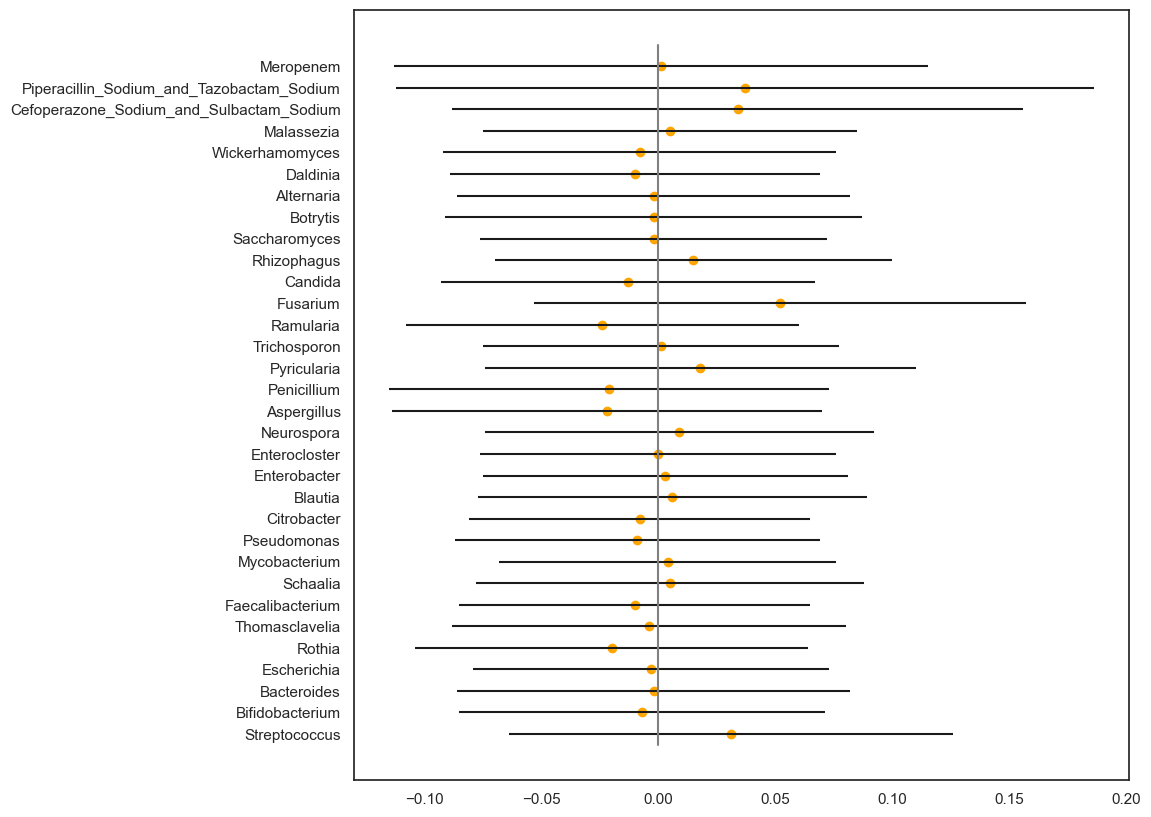

<Figure size 640x480 with 0 Axes>

In [101]:
save_all_X = all_X.copy()
save_all_Y = all_Y.copy()

store_all_interactions = pd.DataFrame()
store_intercepts = pd.DataFrame()

tmp = save_all_X.copy()
tmp[tmp>0]=1

for focal_species in all_Y.columns:
    
    my_all_X = save_all_X.copy()
    my_all_Y = save_all_Y.copy()

    # Drop samples without focal species        
    my_all_X = my_all_X.drop(my_all_X.loc[my_all_X[focal_species] ==0,:].index)
    my_all_Y = my_all_Y.loc[my_all_X.index,:].copy()
    
    # 创建my_all_Y的副本
    my_all_Y_copy = my_all_Y.copy()


    
    if len(my_all_Y) > 10:

        # Standardize all X variables
        tmp = StandardScaler().fit_transform(my_all_X)
        my_all_X = pd.DataFrame(tmp, index = my_all_X.index, columns = my_all_X.columns)
        
        
        model = pm.Model()
 #       X_taxa = my_all_X.copy()[my_all_Y.columns]
        X_taxa = my_all_X.copy()[my_all_Y_copy.columns]
        X_drugs = my_all_X.copy().drop(X_taxa.columns, axis=1)
               
        X_taxa = X_taxa.drop(X_taxa.loc[:,X_taxa.sum()==0].columns,axis=1)
        X_drugs = X_drugs.drop(X_drugs.loc[:,X_drugs.sum()==0].columns,axis=1)

        y = my_all_Y[focal_species].copy()

        
        # Set up priors for model
        
        Sigma_taxa = np.matmul(X_taxa.T.values, X_taxa.values) * 0.5
        Sigma_taxa += np.diag(np.diag(Sigma_taxa))
        Sigma_taxa = np.linalg.inv(Sigma_taxa)
        #Sigma_taxa = np.identity(len(Sigma_taxa)) # alternatively use identity matrix (results same)
        
        Sigma_drugs = np.matmul(X_drugs.T.values, X_drugs.values) * 0.5
        Sigma_drugs += np.diag(np.diag(Sigma_drugs))
        Sigma_drugs = np.linalg.inv(Sigma_drugs)
        #Sigma_drugs = np.identity(len(Sigma_drugs)) # alternatively use identity matrix (results same)
        
        # For calculating growth rate initialisation
        X_growth = my_all_X.copy()
        X_growth = sm.add_constant(X_growth)
        Y = my_all_Y[focal_species].copy()
        r_model = sm.OLS(Y,X_growth)
    
        results = r_model.fit()
        init_r = results.params['const']
        if init_r < 0:
            init_r = 0
            
        init_r_std= np.std(results.params) # inflate initial prior for intercept
    
        
        with pm.Model() as model:
            
            xi_taxa = pm.Bernoulli('xi_taxa', .5, shape=X_taxa.shape[1])
            tau_taxa = pm.HalfCauchy('tau_taxa', 1)
            beta_taxa = pm.MvNormal('beta_taxa', 0, tau_taxa * Sigma_taxa, shape=X_taxa.shape[1])
            mean_taxa = pm.math.dot(X_taxa, xi_taxa * beta_taxa)
            # 检查 X_drugs 的形状
            print(X_drugs.shape)

            # 在使用之前确保 X_drugs 具有有效的形状
            if X_drugs.shape[1] <= 0:
                raise ValueError("X_drugs 的形状无效。请检查数据或计算。")
 

            xi_drugs = pm.Bernoulli('xi_drugs', .5, shape=X_drugs.shape[1])
            tau_drugs = pm.HalfCauchy('tau_drugs', 1)
            beta_drugs = pm.MvNormal('beta_drugs', 0, tau_drugs * Sigma_drugs, shape=X_drugs.shape[1])
            mean_drugs = pm.math.dot(X_drugs, xi_drugs * beta_drugs)
            
            my_sigma = pm.HalfNormal('my_sigma', 10) 

            
            intercp = pm.Bound(pm.Normal, lower=0.0)('intercp', mu=1.0, tau=(init_r_std**2)*1e2)
            
            my_var = pm.Normal('my_var', mean_drugs + mean_taxa + intercp, my_sigma, observed=y)

            lasso_normal_trace_s = pm.sample(draws =10000,tune=2500, init='adapt_diag', cores=-1)



        my_summary = pm.summary(lasso_normal_trace_s)
        
        store_intercepts.loc[focal_species, 'ic'] = my_summary.loc['intercp','mean']
        
        new_summary = pd.DataFrame()
        for ix, val in enumerate(X_taxa.columns):
            #cur_index = 'beta_taxa__' + str(ix)
            cur_index = 'beta_taxa[' + str(ix) + ']'
            cur_mean = my_summary.loc[cur_index, 'mean']
            cur_sd = my_summary.loc[cur_index, 'sd']
            try:
                rename_val = val + '_' + otu_table.loc[val, 'family']
            except:
                rename_val = val
            new_summary.loc[rename_val, 'cur_mean'] = cur_mean
            new_summary.loc[rename_val, 'cur_sd'] = cur_sd
            store_all_interactions.loc[focal_species, val] = cur_mean



        for ix, val in enumerate(X_drugs.columns):
            #cur_index = 'beta_drugs__' + str(ix)
            cur_index = 'beta_drugs[' + str(ix) + ']'
            cur_mean = my_summary.loc[cur_index, 'mean']
            cur_sd = my_summary.loc[cur_index, 'sd']
            try:
                rename_val = val + '_' + otu_table.loc[val, 'family']
            except:
                rename_val = val
            new_summary.loc[rename_val, 'cur_mean'] = cur_mean
            new_summary.loc[rename_val, 'cur_sd'] = cur_sd
            store_all_interactions.loc[focal_species, val] = cur_mean


        try:
            print(focal_species, otu_table.loc[focal_species, 'family'])
        except:
            print(focal_species)
        sns.set_style('white')
        plt.figure(figsize=(10,10))

        plt.scatter(x = new_summary.cur_mean, y = new_summary.index, c='orange')
        plt.barh(y = new_summary.index,
                width = new_summary.cur_mean,
                height=0.0,
                xerr= new_summary.cur_sd)
        plt.plot([0,0],[-0.5,len(new_summary)+0.0],'gray')
        plt.savefig(f'E:/projects/肝移植/fig3/glv/figure/wo/{focal_species}.pdf', format='pdf')
        plt.show()
        plt.clf()
    
   # break

In [79]:
new_summary

,cur_mean,cur_sd
Veillonella,0.012,0.090
Klebsiella,-0.012,0.094
Bacteroides,-0.005,0.088
Bifidobacterium,-0.005,0.087
Escherichia,-0.002,0.089
Faecalibacterium,-0.005,0.089
Phocaeicola,0.008,0.091
Ramularia,-0.009,0.088
Aspergillus,0.002,0.096
Penicillium,0.003,0.092


In [83]:
my_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
xi_taxa[0],0.498,0.500,0.000,1.000,0.002,0.001,57039.0,20000.0,1.0
xi_taxa[1],0.502,0.500,0.000,1.000,0.002,0.002,50752.0,20000.0,1.0
xi_taxa[2],0.496,0.500,0.000,1.000,0.002,0.001,60787.0,20000.0,1.0
xi_taxa[3],0.493,0.500,0.000,1.000,0.002,0.001,71977.0,20000.0,1.0
xi_taxa[4],0.493,0.500,0.000,1.000,0.002,0.001,56370.0,20000.0,1.0
xi_taxa[5],0.492,0.500,0.000,1.000,0.002,0.001,65951.0,20000.0,1.0
xi_taxa[6],0.498,0.500,0.000,1.000,0.002,0.001,63451.0,20000.0,1.0
xi_taxa[7],0.500,0.500,0.000,1.000,0.002,0.002,49667.0,20000.0,1.0
xi_taxa[8],0.492,0.500,0.000,1.000,0.002,0.001,62163.0,20000.0,1.0
xi_taxa[9],0.492,0.500,0.000,1.000,0.002,0.001,69963.0,20000.0,1.0


In [90]:
lasso_normal_trace_s

<MultiTrace: 2 chains, 10000 iterations, 12 variables>

In [102]:
store_all_interactions

,Veillonella,Klebsiella,Bifidobacterium,Bacteroides,Escherichia,Rothia,Phocaeicola,Mediterraneibacter,Thomasclavelia,Faecalibacterium,...,Cefoperazone_Sodium_and_Sulbactam_Sodium,Meropenem,Streptococcus,Citrobacter,Blautia,Trichosporon,Fusarium,Piperacillin_Sodium_and_Tazobactam_Sodium,Candida,Enterococcus
Streptococcus,0.009,-0.008,-0.004,-0.004,-0.006,-0.002,0.012,-0.004,0.002,-0.003,...,0.012,-0.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Veillonella,0.008,-0.017,-0.003,-0.008,-0.002,-0.004,0.011,-0.004,0.001,-0.003,...,0.009,-0.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Klebsiella,0.007,-0.011,-0.007,-0.002,-0.005,-0.003,0.009,-0.002,0.000,0.001,...,0.004,-0.012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bifidobacterium,0.013,-0.009,-0.006,-0.000,-0.012,-0.001,0.012,-0.004,0.001,0.004,...,0.014,-0.005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enterococcus,0.009,-0.006,0.001,0.003,-0.002,-0.005,0.012,-0.000,-0.002,0.002,...,0.023,0.003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bacteroides,0.009,-0.004,-0.009,0.001,-0.011,-0.007,0.014,0.001,-0.002,-0.001,...,0.004,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Escherichia,0.008,-0.008,-0.006,0.000,-0.005,-0.007,0.008,-0.004,-0.002,-0.003,...,0.015,-0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rothia,0.007,-0.007,-0.003,-0.002,-0.004,-0.006,0.009,-0.002,-0.000,0.000,...,0.015,-0.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phocaeicola,0.012,-0.006,-0.009,-0.001,-0.007,-0.002,0.012,0.000,-0.003,0.000,...,0.016,-0.005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mediterraneibacter,0.012,-0.006,-0.005,0.001,-0.005,-0.006,0.009,NaN,0.000,0.001,...,0.001,-0.010,0.016,-0.004,-0.004,0.003,0.010,0.007,NaN,NaN


In [117]:
#st.write_file('./all_interactions.txt', store_all_interactions)

In [107]:
store_all_interactions.to_csv('./all_interactions.txt', sep='\t')

In [3]:
store_all_interactions = pd.read_csv('E:/projects/肝移植/fig3/glv/wo/all_interactions.txt',sep='\t',index_col=0)
store_all_interactions

,Veillonella,Klebsiella,Bifidobacterium,Bacteroides,Escherichia,Rothia,Phocaeicola,Mediterraneibacter,Thomasclavelia,Faecalibacterium,...,Cefoperazone_Sodium_and_Sulbactam_Sodium,Meropenem,Streptococcus,Citrobacter,Blautia,Trichosporon,Fusarium,Piperacillin_Sodium_and_Tazobactam_Sodium,Candida,Enterococcus
Streptococcus,0.009,-0.008,-0.004,-0.004,-0.006,-0.002,0.012,-0.004,0.002,-0.003,...,0.012,-0.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Veillonella,0.008,-0.017,-0.003,-0.008,-0.002,-0.004,0.011,-0.004,0.001,-0.003,...,0.009,-0.025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Klebsiella,0.007,-0.011,-0.007,-0.002,-0.005,-0.003,0.009,-0.002,0.000,0.001,...,0.004,-0.012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bifidobacterium,0.013,-0.009,-0.006,-0.000,-0.012,-0.001,0.012,-0.004,0.001,0.004,...,0.014,-0.005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enterococcus,0.009,-0.006,0.001,0.003,-0.002,-0.005,0.012,-0.000,-0.002,0.002,...,0.023,0.003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bacteroides,0.009,-0.004,-0.009,0.001,-0.011,-0.007,0.014,0.001,-0.002,-0.001,...,0.004,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Escherichia,0.008,-0.008,-0.006,0.000,-0.005,-0.007,0.008,-0.004,-0.002,-0.003,...,0.015,-0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rothia,0.007,-0.007,-0.003,-0.002,-0.004,-0.006,0.009,-0.002,-0.000,0.000,...,0.015,-0.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phocaeicola,0.012,-0.006,-0.009,-0.001,-0.007,-0.002,0.012,0.000,-0.003,0.000,...,0.016,-0.005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mediterraneibacter,0.012,-0.006,-0.005,0.001,-0.005,-0.006,0.009,NaN,0.000,0.001,...,0.001,-0.010,0.016,-0.004,-0.004,0.003,0.010,0.007,NaN,NaN


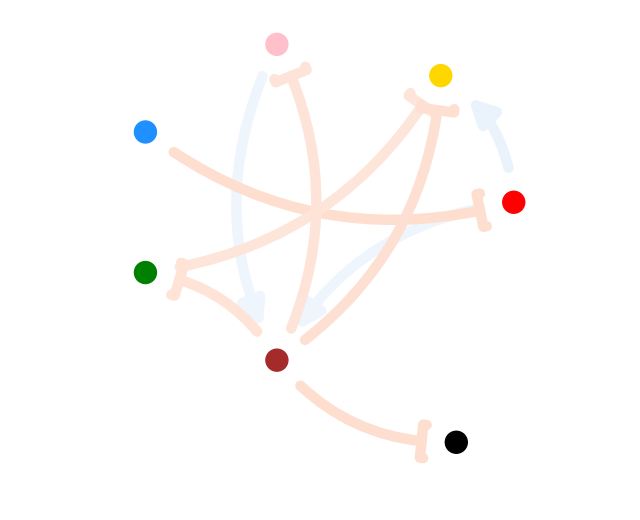

图形已保存为output_plot.pdf


In [33]:
### Plot positive edges ###
#G=nx.from_numpy_matrix(np.array(cm_pos),
#                       create_using=nx.MultiDiGraph())
f, ax = plt.subplots(1,figsize=(8, 6.5))
my_list = ['Veillonella',
            'Bifidobacterium',
    'Faecalibacterium',
           'Klebsiella',
        'Escherichia',
           'Streptococcus','Candida']
### Split interactions into positive and negative for plotting ###
cur_matrix = store_all_interactions.copy()
cur_matrix[abs(cur_matrix) <0.01]=0 # filter out very weak interactions
cur_matrix = cur_matrix.loc[my_list, my_list].T
cm_pos = cur_matrix.copy()
cm_pos[cm_pos<0]=0
cm_neg = cur_matrix.copy()
cm_neg[cm_neg>0]=0
import networkx as nx
G=nx.from_numpy_array(np.array(cm_pos),
                       create_using=nx.MultiDiGraph())

pos = nx.layout.circular_layout(G)
pos[6] = (pos[6][0] + 0.08, pos[6][1]-0.7)

M = G.number_of_edges()
edge_colors = np.zeros(M)
for ix, e in enumerate(G.edges(data=True)):
    edge_colors[ix] = abs(e[2]['weight'])

for cix, cn in enumerate(G.edges()):
    e = FancyArrowPatch(pos[cn[0]],
                        pos[cn[1]],
                            arrowstyle='-|>',
                            connectionstyle='arc3,rad=0.25',
                            mutation_scale=35.0,
                            lw=7.5,
                            color=cm.Blues(edge_colors[cix]*5),
                            shrinkA=25,
                            shrinkB=25)
    ax.add_patch(e)

    
### Plot negative edges ###
#G=nx.from_numpy_matrix(np.array(cm_neg),
#                      create_using=nx.MultiDiGraph())
G=nx.from_numpy_array(np.array(cm_neg),
                       create_using=nx.MultiDiGraph())

M = G.number_of_edges()
edge_colors = np.zeros(M)
for ix, e in enumerate(G.edges(data=True)):
    edge_colors[ix] = abs(e[2]['weight'])

for cix, cn in enumerate(G.edges()):
    e = FancyArrowPatch(pos[cn[0]],
                        pos[cn[1]],
                            arrowstyle='-[',
                            connectionstyle='arc3,rad=0.25',
                            mutation_scale=12.0,
                            lw=7.5,
                            color=cm.Reds(edge_colors[cix]*8),
                            shrinkA=25,
                            shrinkB=25)
    ax.add_patch(e)


### Plot nodes ###
node_colors = ['red', 'gold','pink','dodgerblue', 'green', 'brown','black']
nx.draw_networkx_nodes(G,pos,nodelist=range(7),node_shape='o', node_size=250, node_color= node_colors[0:7])
#nx.draw_networkx_nodes(G,pos,nodelist=[5],node_shape='o', node_size=250, node_color=['black'])
    
    
### Fix axis ###
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])
plt.axis('off')
plot_margin = 0.5
x0, x1, y0, y1 = plt.axis()
plt.axis((x0 - plot_margin,
          x1 + plot_margin,
          y0 -plot_margin-0.3,
          y1 + 0.09))

plt.savefig("E:/projects/肝移植/fig3/glv/new/wo.g.ca.pdf", format="pdf", bbox_inches='tight')  # 导出为PDF
plt.show()

print("图形已保存为output_plot.pdf")

In [145]:
# Get antimicrobial interactions
abx_matrix = store_all_interactions.copy()
abx_matrix = abx_matrix.drop(my_bacteria,axis=1)
#abx_matrix = abx_matrix.drop(my_fungi,axis = 1).fillna(0)
#abx_matrix[abs(abx_matrix) < 0.001] = 0

In [139]:
## Split up antimicrobial matrix
# bacteria / antibiotics
#bac_abx = abx_matrix.loc[my_bacteria,antibacterials].copy().dropna(1)
bac_abx = abx_matrix.copy().dropna()
store_abx_tmp = pd.DataFrame()
for col in bac_abx.columns:
    tmp = bac_abx.loc[:,col]
    #store_abx_tmp = pd.concat([store_abx_tmp, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_abx_tmp = pd.concat([store_abx_tmp, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_abx_tmp = store_abx_tmp.reset_index().drop(['index'], axis = 1)

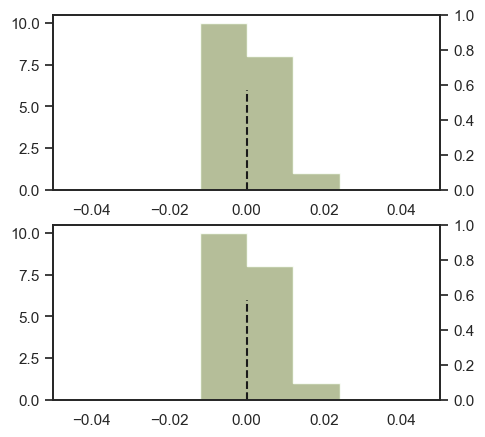

In [152]:
# bacteria / antifungals
#bac_anf = abx_matrix.loc[my_bacteria,antifungals].copy().dropna(1)
bac_anf = abx_matrix.copy().dropna()
store_anf_tmp = pd.DataFrame()
for col in bac_anf.columns:
    tmp = bac_anf.loc[:,col]
    #store_anf_tmp = pd.concat([store_anf_tmp, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_anf_tmp = pd.concat([store_anf_tmp, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_anf_tmp = store_anf_tmp.reset_index().drop(['index'],axis = 1)

# fungi / antibiotics
#fun_abx = abx_matrix.loc[my_fungi,antibacterials].copy().drop(['Aspergillus'])
fun_abx = abx_matrix.copy()
fun_abx  = fun_abx.dropna()
store_abx_tmp_fun = pd.DataFrame()
for col in fun_abx.columns:
    tmp = fun_abx.loc[:,col]
    #store_abx_tmp_fun = pd.concat([store_abx_tmp_fun, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_abx_tmp_fun = pd.concat([store_abx_tmp_fun, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_abx_tmp_fun = store_abx_tmp_fun.reset_index().drop(['index'],axis = 1)

# fungi / antifungals
#fun_anf = abx_matrix.loc[my_fungi,antifungals].copy().drop(['Aspergillus'])
fun_anf = abx_matrix.copy()
fun_anf  = fun_anf.dropna()
store_anf_tmp_fun = pd.DataFrame()
for col in fun_anf.columns:
    tmp = fun_anf.loc[:,col]
    #store_anf_tmp_fun = pd.concat([store_anf_tmp_fun, pd.DataFrame(tmp[tmp! = 0].get_values())])
    store_anf_tmp_fun = pd.concat([store_anf_tmp_fun, pd.DataFrame(tmp[tmp!=0].to_numpy())])
store_anf_tmp_fun = store_anf_tmp_fun.reset_index().drop(['index'],axis = 1)


# Plot separate histograms
fig, ax = plt.subplots(2,1, figsize = (5,5))

thresh_val = 0.05
store_abx_tmp[store_abx_tmp < -thresh_val] = -thresh_val
store_abx_tmp[store_abx_tmp > thresh_val] = thresh_val

store_anf_tmp[store_anf_tmp < -thresh_val] = -thresh_val
store_anf_tmp[store_anf_tmp > thresh_val] = thresh_val

store_abx_tmp_fun[store_abx_tmp_fun < -thresh_val] = -thresh_val
store_abx_tmp_fun[store_abx_tmp_fun > thresh_val] = thresh_val

store_anf_tmp_fun[store_anf_tmp_fun < -thresh_val] = -thresh_val
store_anf_tmp_fun[store_anf_tmp_fun > thresh_val] = thresh_val


my_bins = np.linspace(-3,3,51)*0.1
ax[0].hist(store_abx_tmp.values,
         density = False,
         bins = my_bins,
        histtype = 'stepfilled',
          color = [179/255,129/255,176/255])

ax0_2 = ax[0].twinx() 
ax[0].hist(store_anf_tmp.values,
         density = False,
         bins = my_bins,
        alpha = 0.75,
        histtype = 'stepfilled',
          color = [182/255,212/255,146/255])
ax[0].plot([0,0],[0,6],'k--')
ax[0].set_xlim([-0.05,0.05])

ax[1].hist(store_abx_tmp_fun.values,
         density = False,
         bins = my_bins,
        histtype = 'stepfilled',
          color = [179/255,129/255,176/255])
ax1_2 = ax[1].twinx() 

ax[1].hist(store_anf_tmp_fun.values,
         density = False,
         bins = my_bins,
        alpha = 0.75,
        histtype = 'stepfilled',
        color = [182/255,212/255,146/255])
ax[1].plot([0,0],[0,6],'k--')
ax[1].set_xlim([-0.05,0.05])

plt.show()

In [148]:
# Get just taxa interactions
cur_matrix = store_all_interactions.copy()
cur_matrix = cur_matrix.drop(abx_matrix.columns, axis = 1)
#cur_matrix = cur_matrix.loc[:, cur_matrix.index]
#cur_matrix[abs(cur_matrix) < 0.001] = 0

In [129]:
# Get just taxa interactions
cur_matrix = store_all_interactions.copy()
cur_matrix = cur_matrix.drop(abx_matrix.columns, axis = 1)
#cur_matrix = cur_matrix.loc[:, cur_matrix.index]
#cur_matrix[abs(cur_matrix) <0.001]=0


# Go through and count interactions
count_ints = pd.DataFrame(0, index = ['interaction'], columns = ['-/-', '-/o', '+/-', '+/o', '+/+'])

In [149]:
for ix_sp in cur_matrix.index:
    for col_sp in cur_matrix.columns:
        
        if col_sp != ix_sp:
            ci_focal = cur_matrix.loc[ix_sp, col_sp]
            ci_pair = cur_matrix.loc[col_sp, ix_sp]
            #ci_pair = cur_matrix.loc[ix_sp, col_sp]
            

            if ci_focal > 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/+'] = count_ints.loc['interaction', '+/+'] + 1 # pp
                if ci_pair < 0:
                    count_ints.loc['interaction', '+/-'] = count_ints.loc['interaction', '+/-'] + 1 # pm
                if ci_pair == 0:
                    count_ints.loc['interaction', '+/o'] = count_ints.loc['interaction', '+/o'] + 1 # po

            if ci_focal < 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/-'] = count_ints.loc['interaction', '+/-'] + 1# mp
                if ci_pair < 0:
                    count_ints.loc['interaction', '-/-'] = count_ints.loc['interaction', '-/-'] + 1# mm
                if ci_pair == 0:
                    count_ints.loc['interaction', '-/o'] = count_ints.loc['interaction', '-/o'] + 1# mo

            if ci_focal == 0:
                if ci_pair > 0:
                    count_ints.loc['interaction', '+/o'] = count_ints.loc['interaction', '+/o'] + 1# op
                if ci_pair < 0:
                    count_ints.loc['interaction', '-/o'] = count_ints.loc['interaction', '-/o'] + 1# om 
                
        
# Plot result
fig, ax = plt.subplots(1,1, figsize=(2,5))
colors = ['darkred', 'tomato', 'khaki', 'royalblue', 'darkblue']
count_ints=count_ints/count_ints.sum(1).values[0]
count_ints.plot(kind='bar',
                stacked=True,
                #colors = colors,
                color = colors,
                ax=ax)  
ax.set_ylim(0,1)
ax.legend(bbox_to_anchor=(01.6, 1.00),
          ncol=1, fancybox=True)
plt.show()

KeyError: 'Neurospora'

C:\Users\15837\AppData\Local\Temp\ipykernel_24696\2571230634.py:26: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax1.get_shared_y_axes().join(ax2)


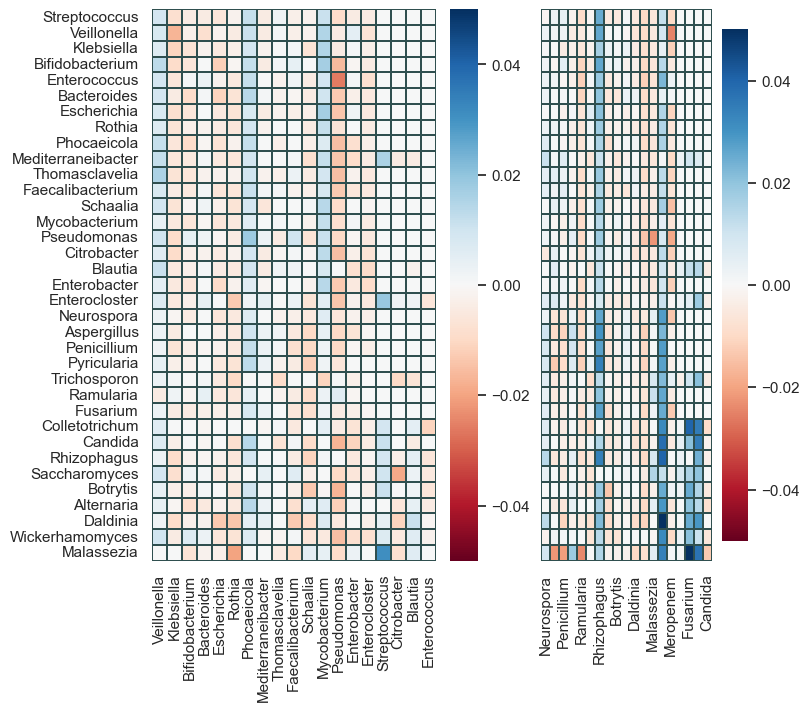

In [153]:
fig = plt.figure(constrained_layout=True, figsize=(8,7))

gs = GridSpec(1, 8, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:5])
ax2 = fig.add_subplot(gs[0, 5:8])#, sharey=ax1)

clusters =  sns.heatmap(cur_matrix.fillna(0),
               cmap='RdBu',
               center=0,
               vmin=-0.05,
               vmax=0.05,
              square=False, ax=ax1,cbar=True,yticklabels=True,linewidths=0.05,
                  linecolor = 'darkslategray',)

clusters =  sns.heatmap(abx_matrix.fillna(0),
               cmap='RdBu',
               center=0,
               vmin=-0.05,
               vmax=0.05,
              square=False,
                ax=ax2,
              cbar=True,
                yticklabels=False,
                       linewidths=0.05,
                  linecolor = 'darkslategray',)
ax1.get_shared_y_axes().join(ax2)
plt.show()

